## Import the required libraries

In [1]:
color_drop_out={
        'Graduate': '#0072B2',
        'Dropout': '#D55E00'
    }

In [2]:
# Data pre-processing
from sklearn.preprocessing import StandardScaler

# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning Models
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import lightgbm as lgb


# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [3]:
# PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pyspark.sql.functions as F

# Data wrangling
import numpy as np
import pandas as pd  # Still needed for visualization conversions
from tqdm import tqdm
import seaborn as sns

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# PySpark ML imports
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder, PCA
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline

# For sklearn metrics (can still use for final evaluation)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


# Where the exported tables and figures go
from pathlib import Path
FIG_DIR = Path('03_KetQua_Hinh/kaggle')
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    """Write a Plotly figure to 03_KetQua_Hinh/kaggle/ AND display it.

    Plotly figures are rendered by the browser and are NOT stored inside the
    .ipynb file, so they disappear the moment the notebook is exported to PDF
    or Word. Writing a PNG alongside keeps every chart available to the thesis.
    """
    fig.write_image(FIG_DIR / f'{name}.png', scale=2)
    fig.show()


Initialise the Spark session

In [4]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Student Performance Analysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/11 16:27:45 WARN Utils: Your hostname, MacBook-Pro-cua-Koh.local, resolves to a loopback address: 127.0.0.1; using 192.168.2.1 instead (on interface bridge0)
26/08/11 16:27:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/08/11 16:27:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/08/11 16:27:46 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


### 1. Load and understand the data

In [5]:
df = spark.read.option("header", "true") \
               .option("sep", ";") \
               .option("inferSchema", "true") \
               .csv("data/student's dropout dataset.csv")

print(f"Loaded: {df.count()} rows · {len(df.columns)} columns")
df.show(5)

Loaded: 4424 rows · 37 columns
+--------------+----------------+-----------------+------+----------------------------+----------------------+------------------------------+-----------+----------------------+----------------------+-------------------+-------------------+---------------+---------+-------------------------+------+-----------------------+------+------------------+-----------------+-------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------+--------------+-----+--------+
|Marital status|Application mode|Application order|Course|Daytime/evening attendance\t

26/08/11 16:27:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


# Data dictionary

Source: <https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success>

## 1. Personal & admission information

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Marital status** | Marital status of the student (1 = single, 2 = married, 3 = divorced, etc.) | 1 | Categorical |
| **Application mode** | How the student applied (e.g. 1 = general contingent, 17 = transfer, 15 = international, 39 = re-admission) | 17 | Categorical |
| **Application order** | Preference order of the application (1 = first choice) | 1 | Numeric |
| **Course** | Degree programme code | 9773 | Categorical |
| **Daytime/evening attendance** | Attendance type: 1 = daytime, 0 = evening | 1 | Binary |
| **Previous qualification** | Qualification obtained before enrolling (e.g. 1 = secondary, 2 = technical secondary, 4 = bachelor, 19 = foreign) | 1 | Categorical |
| **Previous qualification (grade)** | Grade of the previous qualification | 122.0 | Numeric |
| **Nacionality** | Nationality (1 = Portuguese, 2 = EU, 6 = non-EU, etc.) — misspelt in the source file | 1 | Categorical |

---

## 2. Family background

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Mother's qualification** | Mother's education level (1 = none, 19 = bachelor, 37 = master, 38 = doctorate) | 37 | Categorical |
| **Father's qualification** | Father's education level (same coding as the mother's column) | 38 | Categorical |
| **Mother's occupation** | Mother's occupation (codes 1–9: manual worker, clerk, professional, manager, etc.) | 9 | Categorical |
| **Father's occupation** | Father's occupation | 9 | Categorical |

---

## 3. Admission and personal circumstances

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Admission grade** | Admission score (range 95–200) | 141.5 | Numeric |
| **Displaced** | Whether the student is displaced from their home region (0 = no, 1 = yes) | 0 | Binary |
| **Educational special needs** | Whether the student has special educational needs (0 = no, 1 = yes) | 0 | Binary |
| **Debtor** | Whether the student owes tuition (0 = no, 1 = yes) | 0 | Binary |
| **Tuition fees up to date** | Whether tuition is fully paid (0 = no, 1 = yes) | 1 | Binary |
| **Gender** | Gender (0 = female, 1 = male) | 1 | Binary |
| **Scholarship holder** | Whether the student holds a scholarship (0 = no, 1 = yes) | 0 | Binary |
| **Age at enrollment** | Age when enrolling | 19 | Numeric |
| **International** | International student (0 = no, 1 = yes) | 0 | Binary |

---

## 4. First semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 1st sem (credited)** | Units credited from prior study (exempted) | 0 | Numeric |
| **Curricular units 1st sem (enrolled)** | Units the student enrolled in | 6 | Numeric |
| **Curricular units 1st sem (evaluations)** | Number of assessments taken in semester 1 | 9 | Numeric |
| **Curricular units 1st sem (approved)** | Units passed in semester 1 | 5 | Numeric |
| **Curricular units 1st sem (grade)** | Average grade in semester 1 | 13.4 | Numeric |
| **Curricular units 1st sem (without evaluations)** | Units with no assessment taken (missed exams) | 0 | Numeric |

---

## 5. Second semester — curricular data

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Curricular units 2nd sem (credited)** | Units credited in semester 2 | 0 | Numeric |
| **Curricular units 2nd sem (enrolled)** | Units enrolled in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (evaluations)** | Number of assessments taken in semester 2 | 10 | Numeric |
| **Curricular units 2nd sem (approved)** | Units passed in semester 2 | 6 | Numeric |
| **Curricular units 2nd sem (grade)** | Average grade in semester 2 | 12.4 | Numeric |
| **Curricular units 2nd sem (without evaluations)** | Units with no assessment taken in semester 2 | 0 | Numeric |

---

## 6. Economic context at enrolment

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Unemployment rate** | National unemployment rate (%) | 10.8 | Numeric |
| **Inflation rate** | Inflation rate (%) | 1.4 | Numeric |
| **GDP** | GDP growth (%) | 1.74 | Numeric |

---

## 7. Target variable

| Column | Description | Example | Type |
|--------|--------------|----------|------|
| **Target** | Final academic outcome: `Dropout`, `Enrolled` or `Graduate` | Graduate | Categorical |

---

## Summary of the variable groups

| Group | Content | Purpose |
|------------|----------------|-----------|
| Personal / admission | Individual characteristics and entry route | Describe the student at intake |
| Family | Parents' education and occupation | Capture family influence |
| Academic (semesters) | Study results per semester | Predict dropout or graduation |
| Economic | National economic conditions | Capture the wider context |
| Target | Class label | Variable to be predicted |

### 2. Clean the data before further processing (feature encoding, normalisation, training, etc.)

Two column names in the source file need fixing:

- `"Nacionality"` — misspelt, it should be `"Nationality"`
- `"Daytime/evening attendance\t"` — carries a stray **tab character (`\t`)** at the end

In [6]:
data = df.withColumnRenamed('Nacionality', 'Nationality')\
         .withColumnRenamed('Daytime/evening attendance\t', 'Daytime/evening attendance')

In [7]:
print(f"Number of rows: {data.count()}")
print(f"Number of columns: {len(data.columns)}")

Number of rows: 4424
Number of columns: 37


In [8]:
data.printSchema()

root
 |-- Marital status: integer (nullable = true)
 |-- Application mode: integer (nullable = true)
 |-- Application order: integer (nullable = true)
 |-- Course: integer (nullable = true)
 |-- Daytime/evening attendance: integer (nullable = true)
 |-- Previous qualification: integer (nullable = true)
 |-- Previous qualification (grade): double (nullable = true)
 |-- Nationality: integer (nullable = true)
 |-- Mother's qualification: integer (nullable = true)
 |-- Father's qualification: integer (nullable = true)
 |-- Mother's occupation: integer (nullable = true)
 |-- Father's occupation: integer (nullable = true)
 |-- Admission grade: double (nullable = true)
 |-- Displaced: integer (nullable = true)
 |-- Educational special needs: integer (nullable = true)
 |-- Debtor: integer (nullable = true)
 |-- Tuition fees up to date: integer (nullable = true)
 |-- Gender: integer (nullable = true)
 |-- Scholarship holder: integer (nullable = true)
 |-- Age at enrollment: integer (nullable = 

In [9]:
data.describe().show()

+-------+------------------+------------------+------------------+-----------------+--------------------------+----------------------+------------------------------+------------------+----------------------+----------------------+-------------------+-------------------+------------------+-------------------+-------------------------+-------------------+-----------------------+-------------------+-------------------+------------------+--------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+-----------------------------------+-----------------------------------+--------------------------------------+-----------------------------------+--------------------------------+----------------------------------------------+------------------+------------------+--------------------+--------+
|summary|    Marit

### What the `describe` output tells us

- The file has **37 columns**: 36 explanatory variables plus the `Target` column.
- The variables are a mix of categorical and numeric types.
- Whether any value is missing is **checked in the next cell** rather than asserted here.

Most categorical variables in the downloaded file have already been converted to numeric codes. For exploratory data analysis (EDA), however, some of these columns are mapped back to their original category labels so the charts are readable.


In [10]:
# Checking for null values — this claim has to be verified, not assumed.
null_counts = data.select([F.count(F.when(F.col(c).isNull(), c)).alias(c)
                           for c in data.columns]).collect()[0].asDict()

missing = {c: n for c, n in null_counts.items() if n > 0}
if missing:
    print('Columns containing missing values:')
    for c, n in missing.items():
        print(f'  {c}: {n}')
else:
    print(f'No missing value in any of the {len(data.columns)} columns '
          f'({data.count()} rows checked).')

assert not missing, f'Unexpected missing values: {missing}'


No missing value in any of the 37 columns (4424 rows checked).


Before starting the visualisation work, a second name — `data_viz` — is bound to the DataFrame.

Spark DataFrames are **immutable**: every `withColumn` returns a *new* DataFrame instead of modifying the existing one. So the label-mapping applied to `data_viz` below (turning numeric codes back into readable text) can never corrupt `data`, which stays the frame used for modelling.

> **One population throughout.** All the exploratory charts below use the **complete set of 4,424 students with all three outcomes** — exactly the population the models are trained on later. Filtering `Enrolled` out for the charts but keeping it for the model would make the percentages in this section disagree with the percentages in the modelling section.


In [11]:
# `data` = the frame used for modelling · `data_viz` = the same frame with
# readable labels for the charts. Spark DataFrames are immutable, so the
# label-mapping below cannot affect `data`.
data_viz = data
print(f'EDA population: {data_viz.count()} students (all three outcomes)')


EDA population: 4424 students (all three outcomes)


In [12]:
data.select('Target').distinct().show()

+--------+
|  Target|
+--------+
|Enrolled|
| Dropout|
|Graduate|
+--------+



The `Target` column holds three values:

| Value | Meaning | Description |
| ---------- | ---------------- | ------------------------------------------------ |
| `Graduate` | Graduated | The student completed the programme. |
| `Dropout` | Dropped out | The student left before completing the programme. |
| `Enrolled` | Still enrolled | The student is still studying. |

In its original form this is a **multi-class classification** problem with three classes: `Graduate`, `Dropout`, `Enrolled`.

Having checked the distinct values of **Target**, the next step is to visualise how students are distributed across the three groups using a **pie chart**.

In [13]:
# NOTE: do NOT assign the aggregation back onto `data_viz`.
# This cell used to read `data_viz = data_viz.groupBy(...)`, which left `data_viz`
# with only [Target, count] and broke EVERY later cell that uses `data_viz`.
target_counts = (
    data_viz
    .groupBy("Target")
    .count()
    .orderBy("Target")
)
target_counts.show()

+--------+-----+
|  Target|count|
+--------+-----+
| Dropout| 1421|
|Enrolled|  794|
|Graduate| 2209|
+--------+-----+



In [14]:
target_counts_pd = target_counts.toPandas()

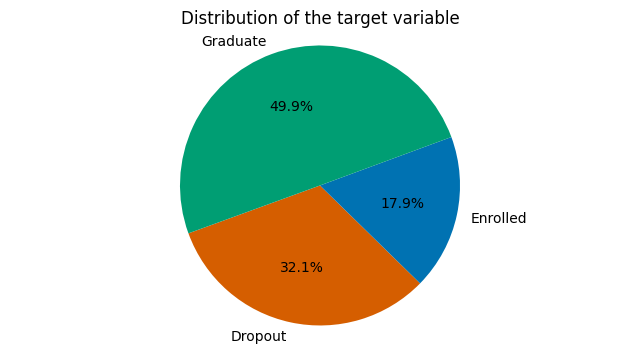

In [15]:
values = target_counts_pd['count']
labels = target_counts_pd['Target'].astype(str)

plt.figure(figsize=(8, 4))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=200,
    colors=['#D55E00', '#0072B2', '#009E73'][:len(values)]
)

plt.title('Distribution of the target variable')
plt.axis('equal')
plt.savefig(FIG_DIR / '15_target_3class.png', dpi=150, bbox_inches='tight')
plt.show()

| Class | Percentage | Meaning |
| --------------- | ---------- | ---------------------------------------- |
| **Graduate** | 49.9% | Completed the programme |
| **Dropout** | 32.1% | Left before completing |
| **Enrolled** | 17.9% | Still studying |

- About half of the students in the dataset graduated (≈ 50%).
- Roughly one third (32%) dropped out — this is the group the risk model needs to identify.
- The remaining 18% are still enrolled; their final outcome is not yet known.

## Binary encoding of the target

In the source data the `Target` column has three values:

- `Dropout` — the student left the programme
- `Enrolled` — the student is still studying
- `Graduate` — the student completed the programme

The research question here is a **binary** one:

> "Will this student drop out or not?"

So the target is encoded as:

- **1** — Dropout
- **0** — Not dropout (both `Enrolled` and `Graduate`)

### Why `Enrolled` is kept and counted as 0

The 794 `Enrolled` students have not left the programme at the time the data was collected, so at that moment they belong to the "not dropout" group. Two alternatives were considered:

| Option | Consequence |
|---|---|
| Drop the `Enrolled` rows | Loses 17.9% of the sample, and produces a model that has never seen a student "in progress" — which is exactly the group an early-warning system has to score |
| **Keep them, labelled 0** ✅ | Uses the whole sample; the label is correct *as of the observation date* |

The limitation this creates is stated openly: some of these students may drop out later, so the label is a **snapshot**, not a final outcome. This is noted again in the conclusions.


In [16]:
# Binary encoding on the FULL dataset — the same population the models use.
# (An earlier version filtered `Enrolled` out here, which made every percentage
#  in the EDA disagree with the percentages in the modelling section.)
data_viz = data_viz.withColumn('Target_Encoded',
                               F.when(F.col('Target') == 'Dropout', 1).otherwise(0))

data_viz_pd = data_viz.toPandas()
print(f'{len(data_viz_pd)} students · dropout = '
      f'{data_viz_pd["Target_Encoded"].mean():.1%}')


4424 students · dropout = 32.1%


In [17]:
# Illustrate the distribution of the encoded target variable
value_counts_series = data_viz_pd['Target_Encoded'].value_counts()
labels_map = {0: 'Not dropout', 1: 'Dropout'}
display_names = [labels_map[val] for val in value_counts_series.index.to_list()]

fig = px.pie(values=value_counts_series.values,
             names=display_names)

fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(colors=['#009E73', '#D55E00']))

fig.update_layout(showlegend=False, height=400, width=800,
                  title='Target distribution after binary encoding')
save_fig(fig, '06_target_binary_pie')

print(value_counts_series.rename(index=labels_map).to_string())


Target_Encoded
Not dropout    3003
Dropout        1421


### Observation

The pie chart shows the share of students who dropped out (1) versus those who did not (0), over the **complete sample of 4,424 students**:

- **0 — did not drop out: 67.9%** (3,003 students = 2,209 `Graduate` + 794 `Enrolled`)
- **1 — dropped out: 32.1%** (1,421 students)

The dataset is therefore **imbalanced**: the non-dropout group is roughly twice the size of the dropout group.

This matters during training, because a model that always answers "not dropout" already scores **67.9% accuracy** without learning anything (**class imbalance bias**). It is the reason the models later use `is_unbalance` / `scale_pos_weight` / `auto_class_weights`, and are selected on **AUC rather than accuracy**.


## Age at enrollment

In [18]:
fig = px.histogram(
    data_viz_pd,
    x='Age at enrollment',
    facet_col='Target',
    color='Target',
    nbins=30,
    histnorm='percent',
    opacity=0.85,
    color_discrete_map={
        'Graduate': '#0072B2',
        'Dropout': '#D55E00',
        'Enrolled': '#009E73'
    }
)

fig.update_layout(
    title={
        'text': 'Age at enrollment by academic outcome',
        'x': 0.5
    },
    xaxis_title='Age at enrollment',
    yaxis_title='Percentage (%)',
    height=450,
    width=1100,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
save_fig(fig, '07_age_by_outcome')

print(data_viz_pd.groupby('Target')['Age at enrollment']
      .describe()[['count', 'mean', '50%', 'max']].round(1).to_string())


           count  mean   50%   max
Target                            
Dropout   1421.0  26.1  23.0  70.0
Enrolled   794.0  22.4  20.0  54.0
Graduate  2209.0  21.8  19.0  62.0


### Observation

- The distribution is right-skewed: most students are in their late teens to early twenties.
- The three groups separate clearly by age: the median age at enrolment is **19** for `Graduate`, **20** for `Enrolled` and **23** for `Dropout`, and the mean is **21.8 / 22.4 / 26.1** years respectively.
- The dropout rate rises among students in their mid-twenties to early thirties, which is consistent with older students carrying work or family commitments alongside their studies.

The next set of charts is mostly pie charts. To avoid repeating code, two helper functions are defined: one builds a dictionary of target counts per category, and the other turns those dictionaries into pie chart traces.


In [19]:
def get_dictionaries(category_list, dfcolumn_name, target_col, dictionary_list, source_pd):
  '''Return a list of dictionaries with the target counts for each category.

  `source_pd` must be passed explicitly. An earlier version rebuilt the frame
  internally from a hard-coded DataFrame, so when the caller had recoded a
  column (e.g. Debtor 0/1 -> 'No'/'Yes') on a DIFFERENT frame, every filter
  matched nothing and the pie charts came out EMPTY without any error.
  '''
  for each_category in category_list:
    subset = source_pd[source_pd[dfcolumn_name] == each_category]
    if subset.empty:
        raise ValueError(
            f"No row matches {dfcolumn_name} == {each_category!r}. "
            f"Available values: {sorted(source_pd[dfcolumn_name].unique())}")
    dictionary_list.append(dict(subset[target_col].value_counts()))
  return dictionary_list


In [20]:
def make_pie(dictionary_list, trace_list, colors_list, textposition = 'inside'):
  '''This function returns a list of traces for pie charts'''
  for dictionary in dictionary_list:
    trace = go.Pie(values = list(dictionary.values()), labels = list(dictionary.keys()),
           textposition = textposition, textinfo='percent+label',
           marker=dict(colors=colors_list))
    trace_list.append(trace)
  return trace_list

## Gender

In [21]:
# Change gender from numerical to categorical
data_viz = data_viz.withColumn('Gender',
                               F.when(col('Gender') == 1, 'Male').otherwise('Female'))


In [22]:
data_viz.select('Gender').show(5)


+------+
|Gender|
+------+
|  Male|
|  Male|
|  Male|
|Female|
|Female|
+------+
only showing top 5 rows


In [23]:
data_viz_pd = data_viz.toPandas()
percent_count = (data_viz_pd['Gender'].value_counts(normalize=True) * 100).round(1)

df_plot = percent_count.reset_index()
df_plot.columns = ['Gender', 'Percentage (%)']

fig = px.bar(
    df_plot,
    x='Percentage (%)',
    y='Gender',
    orientation='h',
    text='Percentage (%)',
    color='Gender',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Gender distribution in the dataset',
        'x': 0.5
    },
    xaxis=dict(
        title='Percentage (%)',
        range=[0, 100],
        ticksuffix='%'
    ),
    yaxis_title='Gender',
    height=420,
    width=720,
    showlegend=False,
    font=dict(size=14)
)

save_fig(fig, '08_gender_distribution')
print(data_viz_pd['Gender'].value_counts().to_string())


Gender
Female    2868
Male      1556


### Observation

- Female students make up about **64.8%** of the dataset (2,868 students).
- Male students make up **35.2%** (1,556 students).

The horizontal bar chart shows a clear gender imbalance in the sample.


Having looked at the overall gender split, the next step is to break gender down by academic outcome (`Target`) — in particular, which group has the higher dropout rate.

In [24]:
# Getting dictionaries for genders
genders = sorted(data_viz_pd['Gender'].unique())
genders_dictionaries = get_dictionaries(genders, 'Gender', 'Target', [], data_viz_pd)
print(dict(zip(genders, genders_dictionaries)))


{'Female': {'Graduate': 1661, 'Dropout': 720, 'Enrolled': 487}, 'Male': {'Dropout': 701, 'Graduate': 548, 'Enrolled': 307}}


In [25]:
df_plot = ( data_viz_pd .groupby(['Gender', 'Target']) .size() .rename('count') .reset_index() )
df_plot['Percentage (%)'] = ( df_plot .groupby('Gender')['count'] .transform(lambda x: x / x.sum() * 100) )
fig = px.bar(
    df_plot,
    x='Target',
    y='Percentage (%)',
    color='Gender',
    barmode='group',
    text=df_plot['Percentage (%)'].round(1).astype(str) + '%',
    color_discrete_map={
        'Male': '#1A4A96',    # blue
        'Female': '#FF8DA1'  # pink
    }
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Academic outcome by gender',
        'x': 0.5
    },
    yaxis_title='Percentage (%)',
    xaxis_title='Academic outcome',
    yaxis=dict(
        range=[0, 100]
    ),
    height=450,
    width=800,
    uniformtext_minsize=12,
    uniformtext_mode='hide'
)

save_fig(fig, '09_outcome_by_gender')

print((pd.crosstab(data_viz_pd['Gender'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1).to_string())


Target  Dropout  Enrolled  Graduate
Gender                             
Female     25.1      17.0      57.9
Male       45.1      19.7      35.2


### Observation

**Male students** (1,556)
- Graduate: 35.2%
- Enrolled: 19.7%
- Dropout: **45.1%**

**Female students** (2,868)
- Graduate: 57.9%
- Enrolled: 17.0%
- Dropout: **25.1%**

The dropout rate among male students is roughly **1.8 times** that of female students.


### Course distribution

In [26]:
from pyspark.sql import functions as F

# The course codes in the UCI file are the ORIGINAL codes (33, 171, 8014 ... 9991), NOT 1..17.
# Using keys 1..17 makes every `Course_name` NULL and leaves the charts empty.
course_mapping = {
    33:   'Biofuel Production Technologies',
    171:  'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)',
}

mapping_expr = F.create_map([F.lit(x) for pair in course_mapping.items() for x in pair])
data_viz = data_viz.withColumn('Course_name', mapping_expr[F.col('Course')])

# Fail fast: any remaining NULL means the mapping does not match the data
n_null = data_viz.filter(F.col('Course_name').isNull()).count()
assert n_null == 0, f'{n_null} rows have an unmapped course code — check course_mapping'
print(f'Mapped {len(course_mapping)} degree programmes, no NULL values left')


Mapped 17 degree programmes, no NULL values left


Total number of students in each course, to see which programmes attract the most students.

In [27]:
# Re-materialise from Spark AFTER `Course_name` was added in the cell above.
data_viz_pd = data_viz.toPandas()
df_course = data_viz_pd.copy()
print(f'{len(df_course)} rows · has Course_name column: {"Course_name" in df_course.columns}')
print(df_course['Course_name'].value_counts().to_string())


4424 rows · has Course_name column: True
Course_name
Nursing                                 766
Management                              380
Social Service                          355
Veterinary Nursing                      337
Journalism and Communication            331
Advertising and Marketing Management    268
Management (evening attendance)         268
Tourism                                 252
Communication Design                    226
Animation and Multimedia Design         215
Social Service (evening attendance)     215
Agronomy                                210
Basic Education                         192
Informatics Engineering                 170
Equiniculture                           141
Oral Hygiene                             86
Biofuel Production Technologies          12


In [28]:
df_course_rate = (
    df_course
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_course_rate['Dropout_rate (%)'] = (
    df_course_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

# Keep only the Dropout rows
df_course_rate = df_course_rate[df_course_rate['Target'] == 'Dropout']

# Sort by rate, descending
df_course_rate = df_course_rate.sort_values(
    'Dropout_rate (%)', ascending=False
)

In [29]:
import plotly.express as px

fig = px.bar(
    df_course_rate,
    x='Dropout_rate (%)',
    y='Course_name',
    orientation='h',
    text=df_course_rate['Dropout_rate (%)'].round(1).astype(str) + '%',
    color='Dropout_rate (%)',
    color_continuous_scale='Reds'
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Dropout rate by degree programme',
        'x': 0.5
    },
    xaxis_title='Dropout rate (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=600,
    width=900,
    coloraxis_showscale=False,
    uniformtext_minsize=11,
    uniformtext_mode='hide'
)

save_fig(fig, '10_dropout_rate_by_course')


In [30]:
df_rate = (
    data_viz_pd
    .groupby(['Course_name', 'Target'])
    .size()
    .rename('count')
    .reset_index()
)

df_rate['Percent'] = (
    df_rate
    .groupby('Course_name')['count']
    .transform(lambda x: x / x.sum() * 100)
)

fig = px.bar(
    df_rate,
    x='Percent',
    y='Course_name',
    color='Target',
    orientation='h',
    barmode='stack',
    color_discrete_map={'Graduate': '#0072B2',
                        'Dropout': '#D55E00',
                        'Enrolled': '#009E73'}
)

fig.update_layout(
    title={
        'text': 'Academic outcome by degree programme',
        'x': 0.5
    },
    xaxis_title='Percentage (%)',
    yaxis_title='Degree programme',
    xaxis=dict(range=[0, 100]),
    height=650,
    width=1000
)

save_fig(fig, '11_outcome_by_course')

print((pd.crosstab(data_viz_pd['Course_name'], data_viz_pd['Target'],
                   normalize='index') * 100).round(1)
      .sort_values('Dropout', ascending=False).to_string())


Target                                Dropout  Enrolled  Graduate
Course_name                                                      
Biofuel Production Technologies          66.7      25.0       8.3
Equiniculture                            55.3      14.9      29.8
Informatics Engineering                  54.1      37.6       8.2
Management (evening attendance)          50.7      20.1      29.1
Basic Education                          44.3      26.0      29.7
Agronomy                                 41.0      17.6      41.4
Oral Hygiene                             38.4      19.8      41.9
Animation and Multimedia Design          38.1      17.2      44.7
Tourism                                  38.1      16.3      45.6
Advertising and Marketing Management     35.4      17.9      46.6
Management                               35.3      28.4      36.3
Social Service (evening attendance)      33.0       9.8      57.2
Journalism and Communication             30.5      10.3      59.2
Veterinary

### Observation

**1. Programmes with the highest dropout rate**

`Biofuel Production Technologies` (66.7%), `Equiniculture` (55.3%), `Informatics Engineering` (54.1%) and `Management — evening attendance` (50.7%) lose more than half of their intake. Note however that `Biofuel Production Technologies` has only **12 students** in the whole dataset, so its 66.7% rests on 8 people and must not be read as a reliable programme-level rate.

**2. Programmes with the highest graduation rate**

`Nursing` (71.5% of 766 students), `Social Service` (69.9% of 355) and `Journalism and Communication` (59.2% of 331) retain their students best. These are also among the largest programmes, so these figures are the most stable in the table.

**3. Programmes with many students still enrolled**

`Informatics Engineering` (37.6%), `Management` (28.4%) and `Basic Education` (26.0%) have a high share of `Enrolled` students, which can indicate a newer programme or a longer expected duration — their final outcome is not yet known.

> Programme size varies from 12 to 766 students, so the percentages for the small programmes carry a wide margin of error. The chart is read as an indication of *where* to look, not as a ranking.


### Marital status

In [31]:
# Map the numeric codes to text labels.
# NOTE: the `otherwise` branch must return the SAME TYPE as the `when` branches.
# Returning the original numeric column makes Spark fail casting 'Single' -> BIGINT.
data_viz = data_viz.withColumn('Marital status',
                               when(col('Marital status') == 1, 'Single')
                               .when(col('Marital status') == 2, 'Married')
                               .when(col('Marital status') == 3, 'Widower')
                               .when(col('Marital status') == 4, 'Divorced')
                               .when(col('Marital status') == 5, 'Facto union')
                               .when(col('Marital status') == 6, 'Legally Separated')
                               .otherwise(col('Marital status').cast('string')))

In [32]:
# Bar chart for Marital status
# Convert to pandas for visualization
data_viz_pd = data_viz.toPandas()
count = data_viz_pd['Marital status'].value_counts()
fig = px.bar(count,  orientation= 'h', text_auto=True)

fig.update_traces(marker=dict(color=['red', 'orange']))
fig.update_layout(height=500, width=800,
                  title='Marital status of the students',
                  showlegend = False,
                  font=dict(size=14),
                  xaxis_title = 'Count',
                  yaxis_title = 'Marital status')
save_fig(fig, '12_marital_status')

- The great majority of students are **single** (3,919 students, roughly 88–90% of the sample). This is expected, since most students are of typical university age.

- A small share are **married** (379 students, about 8–9%), which suggests a group of older or part-time students.

- The remaining categories are very small:

| Status | Count | Note |
| ----------------- | -------- | ------------------------------------------------------ |
| Divorced | 91 | Likely older students or those returning to study |
| Facto union | 25 | Living together without a registered marriage |
| Legally separated | 6 | Negligible |
| Widower | 4 | Very rare |

In [33]:
# Convert to pandas for visualization
data_viz_pd = data_viz.toPandas()

fig = px.histogram(data_viz_pd, x='Marital status', color = 'Target',
                   width = 1200, height = 500,
                   text_auto='.1f', color_discrete_sequence=px.colors.qualitative.Dark2,
                   barnorm = 'percent', barmode = 'group')

fig.update_layout(title='Marital status', yaxis_title = '% of students')

save_fig(fig, '13_marital_status_by_outcome')

Marital status is clearly related to the academic outcome. Single students have the highest graduation rate, while students in more complex family situations (married, separated, divorced) drop out considerably more often — plausibly because of competing demands on their time, finances or emotional capacity.

In [34]:
def sub_plots(chart_to_plot, row, col):
  '''This function generates the list of subplots'''
  cols = chart_to_plot * col
  rows = [cols] * row
  return rows

### Financial situation of the students

Next, the financial situation is analysed to see how scholarship status, debt status and tuition payment status relate to the dropout rate.

In [35]:
# Converting columns back to categorical
data_viz = data_viz.withColumn('Debtor',
                               when(col('Debtor') == 1, 'Yes').otherwise('No'))
data_viz = data_viz.withColumn('Tuition fees up to date',
                               when(col('Tuition fees up to date') == 1, 'Yes').otherwise('No'))
data_viz = data_viz.withColumn('Scholarship holder',
                               when(col('Scholarship holder') == 1, 'Yes').otherwise('No'))

In [36]:
# Getting dictionaries for students in debt / not in debt
data_viz_pd = data_viz.toPandas()      # re-materialise AFTER the Yes/No recoding above
debt = sorted(data_viz_pd['Debtor'].unique())
debt_dictionaries = get_dictionaries(debt, 'Debtor', 'Target', [], data_viz_pd)
print(dict(zip(debt, debt_dictionaries)))


{'No': {'Graduate': 2108, 'Dropout': 1109, 'Enrolled': 704}, 'Yes': {'Dropout': 312, 'Graduate': 101, 'Enrolled': 90}}


In [37]:
# Getting dictionaries for students with tuition fees paid / not paid
tuition = sorted(data_viz_pd['Tuition fees up to date'].unique())
tuition_dictionaries = get_dictionaries(tuition, 'Tuition fees up to date', 'Target', [], data_viz_pd)
print(dict(zip(tuition, tuition_dictionaries)))


{'No': {'Dropout': 457, 'Enrolled': 42, 'Graduate': 29}, 'Yes': {'Graduate': 2180, 'Dropout': 964, 'Enrolled': 752}}


In [38]:
# Getting dictionaries for students with / without a scholarship
scholarship = sorted(data_viz_pd['Scholarship holder'].unique())
scholarship_dictionaries = get_dictionaries(scholarship, 'Scholarship holder', 'Target', [], data_viz_pd)
print(dict(zip(scholarship, scholarship_dictionaries)))


{'No': {'Graduate': 1374, 'Dropout': 1287, 'Enrolled': 664}, 'Yes': {'Graduate': 835, 'Dropout': 134, 'Enrolled': 130}}


In [39]:
# Creating subplots for the pie charts.
# `sorted()` above puts 'No' before 'Yes', so the subplot titles follow that order.
fig = make_subplots(rows=3, cols=2,
                    subplot_titles = ['No debt', 'In debt',
                                      'Tuition unpaid', 'Tuition paid',
                                      'No scholarship', 'Scholarship holder'],
                    specs= sub_plots([{'type':'pie'}], 3,2), vertical_spacing = 0.07)

# Initialize an empty list for traces
traces = []

# Generate traces
make_pie(debt_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(tuition_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])
make_pie(scholarship_dictionaries, traces, ['teal', 'goldenrod', 'slateblue'])

for i, tr in enumerate(traces):
    fig.add_trace(tr, row=i // 2 + 1, col=i % 2 + 1)

fig.update_layout(title="Financial situation of the students", height=1000, width=1000,
                  showlegend=False, title_pad=dict(t=100))
save_fig(fig, '14_financial_situation')

# Print the underlying numbers so the commentary below can be checked against them
for c in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    print(f'\n--- {c} — outcome (%) ---')
    print((pd.crosstab(data_viz_pd[c], data_viz_pd['Target'], normalize='index') * 100)
          .round(1).to_string())



--- Debtor — outcome (%) ---
Target  Dropout  Enrolled  Graduate
Debtor                             
No         28.3      18.0      53.8
Yes        62.0      17.9      20.1

--- Tuition fees up to date — outcome (%) ---
Target                   Dropout  Enrolled  Graduate
Tuition fees up to date                             
No                          86.6       8.0       5.5
Yes                         24.7      19.3      56.0

--- Scholarship holder — outcome (%) ---
Target              Dropout  Enrolled  Graduate
Scholarship holder                             
No                     38.7      20.0      41.3
Yes                    12.2      11.8      76.0


### Observation

Computed on the full sample of 4,424 students:

| Group | n | Dropout | Enrolled | Graduate |
|---|---|---|---|---|
| Not in debt | 3,921 | 28.3% | 18.0% | 53.8% |
| **In debt** | 503 | **62.0%** | 17.9% | 20.1% |
| **Tuition unpaid** | 528 | **86.6%** | 8.0% | 5.5% |
| Tuition paid | 3,896 | 24.7% | 19.3% | 56.0% |
| No scholarship | 3,325 | 38.7% | 20.0% | 41.3% |
| **Scholarship holder** | 1,099 | **12.2%** | 11.8% | 76.0% |

Students who are in debt or who have not paid their tuition drop out far more often — **62.0%** and **86.6%** respectively, against a base rate of 32.1%. Scholarship holders drop out much less (**12.2%**) than students without a scholarship (**38.7%**).

> **Read as association, not as cause.** Unpaid tuition can just as easily be a *consequence* of a student having already decided to leave as a cause of leaving. What the figure establishes is that the payment status is a very strong **early signal**, which is what an alert system needs.

The EDA has now covered how the data is distributed by gender and age, and how features such as the enrolled course and the financial situation relate to dropout. The next stage builds and trains classification models to see whether they agree with these findings.

### Preparing the data — feature selection

The simplest way to see how the independent features relate to each other is a correlation analysis. It highlights which variables carry overlapping information and could be dropped or combined to avoid multicollinearity. A heatmap makes this easy to read.


In [40]:
# Pearson correlation — NUMERIC and BINARY columns only.
# Pearson measures a LINEAR relationship between quantities. Applying it to a
# nominal code (Course 33 ... 9991, Father's occupation 0 ... 195) is meaningless:
# the number is a label, not a magnitude. Those columns are handled separately
# in the next cell with Cramer's V.
data_pd = data.toPandas()

NOMINAL = ['Marital status', 'Application mode', 'Course', 'Nationality',
           'Previous qualification', "Mother's qualification",
           "Father's qualification", "Mother's occupation", "Father's occupation"]

numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Pearson correlation between the numeric / binary features',
                  height=800, width=1400)
save_fig(fig, '01_correlation_numeric')

print(f'{len(numeric_cols)} numeric or binary columns shown · '
      f'{len(NOMINAL)} nominal columns excluded (see the next cell)')


27 numeric or binary columns shown · 9 nominal columns excluded (see the next cell)


### Observation — numeric features

Only one block stands out: the twelve `Curricular units` variables are strongly correlated with each other, as expected — they all measure study progress in the first year. That block is examined on its own two cells below.

Nothing else among the numeric variables is redundant enough to justify removing it.

### The nominal variables need a different statistic

Pearson correlation cannot be used on the nominal columns. `Course` is coded 33, 171, 8014 … 9991 and `Father's occupation` 0 … 195; those numbers are **labels, not magnitudes**, so "correlation" between them measures nothing but the accident of how the codes were assigned.

The correct measure of association between two categorical variables is **Cramér's V** (0 = independent, 1 = one variable determines the other). The next cell computes it — and the answer changes one of the decisions that had been taken on the Pearson figures.


In [41]:
# Cramer's V — association between two CATEGORICAL variables (0 = independent, 1 = determines).
import builtins   # `from pyspark.sql.functions import *` shadows the built-in max/min
from scipy.stats import chi2_contingency

def cramers_v(a, b):
    t = pd.crosstab(a, b)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    r, k = t.shape
    phi2 = chi2 / n
    phi2c = builtins.max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))          # bias correction
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2c / builtins.max(1e-12, builtins.min(kc - 1, rc - 1)))

pairs = [('Nationality', 'International'),
         ("Mother's occupation", "Father's occupation"),
         ("Mother's qualification", "Father's qualification"),
         ('Course', 'Application mode')]

print(f"{'pair':58s} {'Cramer V':>9s} {'Pearson':>9s}")
print('-' * 79)
for a, b in pairs:
    v = cramers_v(data_pd[a], data_pd[b])
    p = data_pd[a].corr(data_pd[b])
    flag = '  <- duplicate' if v > 0.95 else ''
    print(f'{a + " x " + b:58s} {v:9.3f} {p:9.3f}{flag}')

print('\nNationality vs International — the actual contingency table:')
print(pd.crosstab(data_pd['Nationality'] == 1, data_pd['International'],
                  rownames=['Nationality == 1 (Portuguese)'], colnames=['International']))


pair                                                        Cramer V   Pearson
-------------------------------------------------------------------------------
Nationality x International                                    0.998     0.791  <- duplicate
Mother's occupation x Father's occupation                      0.571     0.910
Mother's qualification x Father's qualification                0.431     0.535
Course x Application mode                                      0.168     0.065

Nationality vs International — the actual contingency table:
International                     0    1
Nationality == 1 (Portuguese)           
False                             0  110
True                           4314    0


### What Cramér's V shows

| Pair | Cramér's V | Pearson | Reading |
|---|---|---|---|
| `Nationality` × `International` | **0.998** | 0.791 | One **determines** the other |
| `Mother's occupation` × `Father's occupation` | **0.571** | 0.910 | Related, **not** duplicated |
| `Mother's qualification` × `Father's qualification` | **0.431** | 0.535 | Related, **not** duplicated |
| `Course` × `Application mode` | 0.168 | — | Essentially independent |

Two findings matter here.

**1. `Nationality` and `International` really are the same variable.** The contingency table is exact: `International = 1` for every student whose `Nationality` is not 1 (Portuguese), and 0 for every student whose `Nationality` is 1. There is no row that breaks the rule, so one of the two carries no information the other does not. `Nationality` is dropped.

**2. The parents' variables are *not* duplicates — and Pearson said they were.** For the two occupation columns Pearson reports 0.910, which looks like near-perfect redundancy. Cramér's V reports 0.571. The gap is an artefact of the coding: the occupation codes are ordered by socio-economic group, so both parents of the same household tend to fall in the same numeric range, and Pearson reads that ordering as a linear relationship.

> An earlier version of this notebook dropped `Mother's occupation` and `Father's qualification` on the strength of the Pearson figures. On the correct statistic that decision is **not supported**, and it also runs against the supervisor's guidance, which lists *"Nghề nghiệp & Trình độ học vấn của bố mẹ"* among the important variable groups. **Both columns are kept.**


In [42]:
# PCA is used here ONLY to EXAMINE how correlated the "Curricular units" block is;
# it does NOT replace the original columns.
#
# Reason: this study has to name CAUSES of dropout in terms a human can act on
# ("few curricular units passed in semester 2"). A PCA component is not interpretable —
# telling an advisor that "the PCA component is low" gives them nothing to act on.
# Besides, tree models (LightGBM/XGBoost/CatBoost) do NOT assume independent variables
# the way linear models do, so high correlation is not a reason to compress them.
pca_columns = ['Curricular units 1st sem (credited)',
               'Curricular units 1st sem (enrolled)',
               'Curricular units 1st sem (evaluations)',
               'Curricular units 1st sem (without evaluations)',
               'Curricular units 1st sem (approved)',
               'Curricular units 1st sem (grade)',
               'Curricular units 2nd sem (credited)',
               'Curricular units 2nd sem (enrolled)',
               'Curricular units 2nd sem (evaluations)',
               'Curricular units 2nd sem (without evaluations)',
               'Curricular units 2nd sem (approved)',
               'Curricular units 2nd sem (grade)']

pca_assembler = VectorAssembler(inputCols=pca_columns, outputCol="pca_features")
pca_input = pca_assembler.transform(data)

pca_probe = PCA(k=1, inputCol="pca_features", outputCol="pca_result").fit(pca_input)
var_explained = float(pca_probe.explainedVariance[0])

print(f'One principal component explains {var_explained:.1%} of the variance of '
      f'{len(pca_columns)} "Curricular units" variables.')
print('=> The block measures largely the same thing (study progress), but the original '
      'columns are KEPT so that the SHAP section can name a concrete cause.')

26/08/11 16:28:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


One principal component explains 61.3% of the variance of 12 "Curricular units" variables.
=> The block measures largely the same thing (study progress), but the original columns are KEPT so that the SHAP section can name a concrete cause.


26/08/11 16:28:19 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


### Decision on the `Curricular units` group

The correlation analysis above shows that the `Curricular units` variables are strongly correlated with each other. There are two ways to handle this:

| Option | Advantage | Drawback |
|---|---|---|
| Compress into one PCA component | Fewer dimensions, correlation removed | **Not interpretable** — if SHAP points at "the PCA component", the university cannot tell what to act on |
| **Keep the original columns** ✅ | SHAP can name a concrete cause ("few units passed in semester 2") | Correlation between the variables remains |

This study **keeps the original columns**, for two reasons:

1. **The goal is to identify causes that can be acted on.** The supervisor's guidance also places this block in the *"Academic performance — most important"* group.
2. **Tree models do not assume independent variables** the way linear regression does, so high correlation does not break the model.

### Which columns are dropped

Only **four** columns are removed, each for a reason that survives the check above:

| Column | Reason |
|---|---|
| `Nationality` | Cramér's V = 0.998 with `International` — the contingency table shows one determines the other exactly |
| `Unemployment rate` | Correlation with dropout = +0.013 |
| `Inflation rate` | Correlation with dropout = +0.028 |
| `GDP` | Correlation with dropout = −0.046 |

The three macro-economic indicators are national figures for the year of enrolment, not characteristics of the student: they take only 9–10 distinct values across 4,424 students, and their association with dropout is below 0.05 in absolute value. They also fall outside the four variable groups set out in the supervisor's guidance.

`Mother's occupation` and `Father's qualification`, which an earlier version removed, are **kept** — see the Cramér's V result above.


In [43]:
# Drop only the four columns justified above.
# `Mother's occupation` and `Father's qualification` are KEPT: Pearson made them
# look redundant (0.910 / 0.535) but Cramer's V says otherwise (0.571 / 0.431),
# and the supervisor's guidance lists the parents' variables as important.
columns_to_drop = ['Nationality',                       # Cramer V = 0.998 with International
                   'Unemployment rate',                 # |corr with dropout| = 0.013
                   'Inflation rate',                    # |corr with dropout| = 0.028
                   'GDP']                               # |corr with dropout| = 0.046

data = data.drop(*columns_to_drop)

kept = [c for c in data.columns if c.startswith('Curricular')]
print(f'{len(data.columns)} columns left ({len(data.columns) - 1} features + Target)')
print(f'kept {len(kept)} Curricular units variables:')
for c in kept:
    print(f'  - {c}')
print('\nkept the parents\' variables:')
for c in data.columns:
    if 'Mother' in c or 'Father' in c:
        print(f'  - {c}')


33 columns left (32 features + Target)
kept 12 Curricular units variables:
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (grade)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Curricular units 2nd sem (without evaluations)

kept the parents' variables:
  - Mother's qualification
  - Father's qualification
  - Mother's occupation
  - Father's occupation


In [44]:
# Correlation heat map after the drop — numeric / binary columns only
data_pd = data.toPandas()
numeric_cols = [c for c in data_pd.columns if c not in NOMINAL + ['Target']]
correlation_matrix = data_pd[numeric_cols].corr().round(2)

fig = px.imshow(correlation_matrix, text_auto=True, aspect="auto", color_continuous_scale='RdBu_r')
fig.update_layout(title='Correlation between the numeric features (after the drop)',
                  height=800, width=1400)
save_fig(fig, '02_correlation_after_drop')


## Data processing

Before scaling the data, the target column has to be converted from a category to a number.

In [45]:
# Convert Target column to binary encoding (1 for Dropout, 0 for others).
# `Enrolled_flag` is carried alongside — NOT as a feature — so that the
# sensitivity analysis at the end of the notebook can remove those students
# and check whether the conclusions depend on how they were labelled.
data = data.withColumn('Enrolled_flag',
                       when(col('Target') == 'Enrolled', 1).otherwise(0))
data = data.withColumn('Target_binary',
                       when(col('Target') == 'Dropout', 1).otherwise(0))
data = data.drop('Target').withColumnRenamed('Target_binary', 'Target')
data.select('Target', 'Enrolled_flag').groupBy('Target', 'Enrolled_flag').count().show()


+------+-------------+-----+
|Target|Enrolled_flag|count|
+------+-------------+-----+
|     1|            0| 1421|
|     0|            0| 2209|
|     0|            1|  794|
+------+-------------+-----+



In [46]:
# Prepare features for machine learning
# `Enrolled_flag` is excluded: it is bookkeeping for the sensitivity analysis,
# not information the model is allowed to use.
feature_columns = [c for c in data.columns if c not in ('Target', 'Enrolled_flag')]

# Create vector assembler for all features
vector_assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data_assembled = vector_assembler.transform(data)

print(f'{len(feature_columns)} features assembled')
data_assembled.select("features", "Target").show(5)


32 features assembled
+--------------------+------+
|            features|Target|
+--------------------+------+
|(32,[0,1,2,3,4,5,...|     1|
|[1.0,15.0,1.0,925...|     0|
|(32,[0,1,2,3,4,5,...|     1|
|[1.0,17.0,2.0,977...|     0|
|[2.0,39.0,1.0,801...|     0|
+--------------------+------+
only showing top 5 rows


In [47]:
# Show first 5 target values
data_assembled.select("Target").show(5)

+------+
|Target|
+------+
|     1|
|     0|
|     1|
|     0|
|     0|
+------+
only showing top 5 rows


## Model building

The target is categorical (dropout or not), so this is a classification problem. Two families of models are trained:

**Baseline models** (reference points)
- Logistic regression
- Decision tree
- Linear support vector machine

**Ensemble models** (the focus of this study)
- LightGBM
- XGBoost
- CatBoost

The data is first split into training, validation and test sets, with the random seed fixed to 42 for reproducibility.

> **Order matters: split first, scale afterwards.** Fitting the scaler on the whole dataset and splitting afterwards lets the mean and standard deviation of the test set leak into training. The scaler below is therefore fitted on the **training split only**.

### Splitting the training and test sets


In [48]:
# Split the ASSEMBLED (unscaled) data — scaling happens after the split, below.
train_data, test_data = data_assembled.randomSplit([0.8, 0.2], seed=42)
print(f"Training set count: {train_data.count()}")
print(f"Test set count: {test_data.count()}")


Training set count: 3581


Test set count: 843


Creating validation set

In [49]:
# Split training data into training and validation sets
train_data, val_data = train_data.randomSplit([0.8, 0.2], seed=42)
print(f"Training set count: {train_data.count()}")
print(f"Validation set count: {val_data.count()}")


Training set count: 2918


Validation set count: 663


### Standardising the features — fitted on the training split only

Logistic regression and the linear SVM need standardised inputs. The scaler is
fitted **only on the training split** and then applied unchanged to the validation
and test splits.

Fitting it on the whole dataset first (and splitting afterwards) would let the mean
and standard deviation of the test set leak into training — a textbook case of
**data leakage** that inflates the reported scores.

The tree-based models do not use these scaled columns at all: they are invariant to
monotone transforms, and keeping the raw values is what allows SHAP to report a
risk factor in its original unit.


In [50]:
# Fit the scaler on the TRAINING split only, then apply it to all three splits.
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")
scaler_model = scaler.fit(train_data)          # <- train only, never the full dataset

train_data = scaler_model.transform(train_data)
val_data   = scaler_model.transform(val_data)
test_data  = scaler_model.transform(test_data)

print('Scaler fitted on the training split only '
      f'({train_data.count()} rows), then applied to validation and test.')
train_data.select("features", "scaled_features", "Target").show(3, truncate=60)


Scaler fitted on the training split only (2918 rows), then applied to validation and test.
+------------------------------------------------------------+------------------------------------------------------------+------+
|                                                    features|                                             scaled_features|Target|
+------------------------------------------------------------+------------------------------------------------------------+------+
|(32,[0,1,2,3,4,5,6,7,8,9,10,11,12,15,16,18],[1.0,1.0,1.0,...|(32,[0,1,2,3,4,5,6,7,8,9,10,11,12,15,16,18],[1.7110153643...|     0|
|(32,[0,1,2,3,4,5,6,7,8,9,10,11,16,18],[1.0,1.0,1.0,171.0,...|(32,[0,1,2,3,4,5,6,7,8,9,10,11,16,18],[1.71101536436212,0...|     1|
|(32,[0,1,2,3,4,5,6,7,8,9,10,11,15,16,18],[1.0,1.0,1.0,171...|(32,[0,1,2,3,4,5,6,7,8,9,10,11,15,16,18],[1.7110153643621...|     1|
+------------------------------------------------------------+------------------------------------------------------------+

Baseline Model Accuracy

In [51]:
#import built-in
import builtins
# Calculate the baseline accuracy to beat
# Get the count of each target value
target_counts_df = data_assembled.groupBy("Target").count()
print("Target value counts:")
target_counts_df.show()

# Get the total count of samples
total_count = data_assembled.count()

# Calculate the maximum class count directly within Spark
# The max(count) aggregation finds the highest count from the target_counts_df
max_count = target_counts_df.agg(F.max("count")).collect()[0][0]

# Calculate baseline accuracy
baseline_acc = builtins.round((max_count / total_count) * 100, 3)

print(f'\nTotal samples: {total_count}')
print(f'Maximum class count: {max_count}')
print(f'The baseline accuracy to beat is {baseline_acc}%')
print('=> Accuracy alone is not a meaningful criterion here; AUC is used to select models.')


Target value counts:


+------+-----+
|Target|count|
+------+-----+
|     1| 1421|
|     0| 3003|
+------+-----+




Total samples: 4424
Maximum class count: 3003
The baseline accuracy to beat is 67.88%
=> Accuracy alone is not a meaningful criterion here; AUC is used to select models.


A list is created to hold every trained model together with its best hyper-parameters.

In [52]:
# List of all trained models

trained_models = []

Logistic Regression

In [53]:
# Train a logistic regression model using PySpark
lr_model = LogisticRegression(featuresCol="scaled_features", labelCol="Target", maxIter=1000)
lr_fitted = lr_model.fit(train_data)

# Make predictions
train_predictions = lr_fitted.transform(train_data)
val_predictions = lr_fitted.transform(val_data)
test_predictions = lr_fitted.transform(test_data)

# Evaluate the model's accuracy using PySpark evaluators
evaluator = MulticlassClassificationEvaluator(labelCol="Target", predictionCol="prediction", metricName="accuracy")

lr_acc_train = builtins.round(evaluator.evaluate(train_predictions), 3)
lr_acc_val = builtins.round(evaluator.evaluate(val_predictions), 3)
lr_acc = builtins.round(evaluator.evaluate(test_predictions), 3)

print(f'Accuracy of logistic regression model on the training set is {lr_acc_train * 100}%')
print(f'Accuracy of logistic regression model on the validation set is {lr_acc_val * 100}%')
print(f'Accuracy of logistic regression model on the test set is {lr_acc * 100}%')

# Store model for later use
trained_models = [lr_fitted]

Accuracy of logistic regression model on the training set is 87.6%
Accuracy of logistic regression model on the validation set is 91.60000000000001%
Accuracy of logistic regression model on the test set is 85.2%


Decision Trees

In [54]:
# Test different depth values for Decision Tree
depth_values = list(range(1, 21))

# Create empty list for training data and validation data
training_acc = []
validation_acc = []

evaluator = MulticlassClassificationEvaluator(labelCol="Target", predictionCol="prediction", metricName="accuracy")

for d in tqdm(depth_values):
    tree_model = DecisionTreeClassifier(featuresCol="scaled_features", labelCol="Target", maxDepth=d, seed=42)
    tree_fitted = tree_model.fit(train_data)

    # Training accuracy
    train_pred = tree_fitted.transform(train_data)
    training_acc.append(evaluator.evaluate(train_pred))

    # Validation accuracy
    val_pred = tree_fitted.transform(val_data)
    validation_acc.append(evaluator.evaluate(val_pred))

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:00<00:15,  1.21it/s]

 10%|█         | 2/20 [00:01<00:13,  1.34it/s]

 15%|█▌        | 3/20 [00:02<00:12,  1.40it/s]

 20%|██        | 4/20 [00:02<00:10,  1.46it/s]

...

 85%|████████▌ | 17/20 [00:12<00:02,  1.28it/s]

 90%|█████████ | 18/20 [00:13<00:01,  1.25it/s]

 95%|█████████▌| 19/20 [00:14<00:00,  1.23it/s]

100%|██████████| 20/20 [00:14<00:00,  1.21it/s]

100%|██████████| 20/20 [00:14<00:00,  1.34it/s]

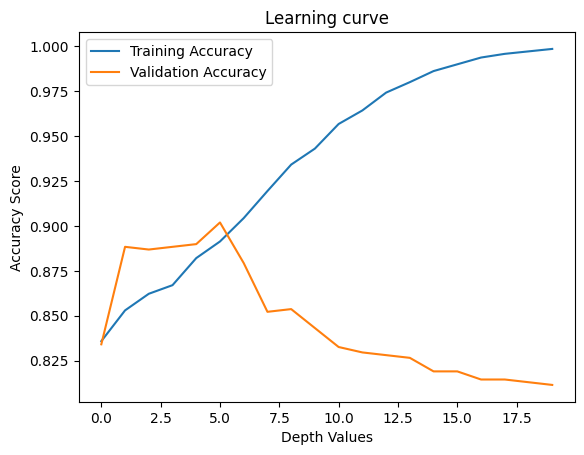

In [55]:
# Plotting learning curve
plt.plot(training_acc, label = 'Training Accuracy')
plt.plot(validation_acc, label = 'Validation Accuracy')
plt.xlabel('Depth Values')
plt.ylabel('Accuracy Score')
plt.title('Learning curve')
plt.legend();
plt.savefig(FIG_DIR / '16_dtree_learning_curve.png', dpi=150, bbox_inches='tight')

The learning curve suggests the best depth is somewhere between 2 and 5. A more reliable way to pick it is to take the index of the highest score in `validation_acc`.

In [56]:
# Best depth value
best_val_acc = builtins.max(validation_acc)
best_depth = validation_acc.index(best_val_acc) +1
print(f'Best depth value with an accuracy of {builtins.round(best_val_acc * 100, 2)}% on the validation set is {best_depth}')

Best depth value with an accuracy of 90.2% on the validation set is 6


In [57]:
# Train a Decision tree model with best depth
tree_model = DecisionTreeClassifier(featuresCol="scaled_features", labelCol="Target", maxDepth=best_depth, seed=42)
tree_fitted = tree_model.fit(train_data)

# Predict target values for test data
test_predictions = tree_fitted.transform(test_data)

# Evaluate the model's accuracy
tree_acc = builtins.round(evaluator.evaluate(test_predictions), 3)
print(f'Accuracy of Decision tree model is {tree_acc * 100}%')

# Add to model list
trained_models.append(tree_fitted)

Accuracy of Decision tree model is 83.5%


Support Vector Machines

In [58]:
# For SVM, PySpark only supports LinearSVC, so we'll use that
# Note: PySpark doesn't have non-linear SVM kernels like sklearn
#
# maxIter=1000, the same budget as the logistic regression above. An earlier
# version passed maxIter=42 — the value of the random seed, put in the wrong
# argument (LinearSVC has no `seed` parameter), which stopped the optimiser
# after 42 iterations, well before it converged.
svm_model = LinearSVC(featuresCol="scaled_features", labelCol="Target", maxIter=1000)
svm_fitted = svm_model.fit(train_data)

# Make predictions
val_predictions = svm_fitted.transform(val_data)

# Evaluate the model's accuracy
svm_acc_val = builtins.round(evaluator.evaluate(val_predictions), 3)
print(f'Validation accuracy of LinearSVC model is {svm_acc_val * 100}%')

# Store the fitted model
svm_linear = [svm_fitted]


Validation accuracy of LinearSVC model is 89.7%


In [59]:
from IPython.display import Markdown
Markdown(f"""
#### PySpark uses LinearSVC which is equivalent to SVM with linear kernel""")


#### PySpark uses LinearSVC which is equivalent to SVM with linear kernel

In [60]:
# Test accuracy of LinearSVC model
test_predictions = svm_fitted.transform(test_data)

# Evaluate the model's accuracy
svm_acc = builtins.round(evaluator.evaluate(test_predictions), 3)
print(f'Accuracy of Support vector classifier model is {svm_acc * 100}%')

# Add to model list
trained_models.append(svm_fitted)

Accuracy of Support vector classifier model is 84.6%


LightGBM Model

In [61]:
# ---------------------------------------------------------------------------
# Convert the Spark DataFrames into pandas / numpy for the sklearn-family models.
#
# The ensemble models use the RAW `features` column, NOT `scaled_features`:
#   * gradient boosted trees are invariant to monotone transforms, so scaling
#     gains nothing;
#   * SHAP has to show the ORIGINAL units ("age 34", "0 units passed").
#     With scaled inputs the explanation reads "Age at enrollment = 4.51",
#     which no academic advisor can act on.
# The baseline models keep `scaled_features` (they do need it).
# ---------------------------------------------------------------------------
def spark_to_array(spark_df, features_col='features', label_col='Target'):
    """Convert a Spark DataFrame to numpy arrays for sklearn-compatible models"""
    rows = spark_df.select(features_col, label_col, 'Enrolled_flag').collect()
    X = np.array([r[features_col].toArray() for r in rows])
    y = np.array([r[label_col] for r in rows])
    e = np.array([r['Enrolled_flag'] for r in rows])
    return X, y, e

X_train, y_train, enr_train = spark_to_array(train_data)
X_val,   y_val,   enr_val   = spark_to_array(val_data)
X_test,  y_test,  enr_test  = spark_to_array(test_data)

# ---------------------------------------------------------------------------
# Nominal variables: the numbers are CODES, not quantities.
# Course 9500 (Nursing) is not "greater than" Course 9003 (Agronomy), so a split
# of the form "Course < 9200" is meaningless. Declaring these columns as
# `category` makes the boosting models split on GROUP MEMBERSHIP instead.
# (This is the encoding step the supervisor's guidance asks for.)
# ---------------------------------------------------------------------------
CATEGORICAL_COLS = [c for c in NOMINAL if c in feature_columns]

_all_rows = np.vstack([X_train, X_val, X_test])
_levels = {c: sorted(set(_all_rows[:, feature_columns.index(c)].astype(int)))
           for c in CATEGORICAL_COLS}

def to_categorical_df(X):
    """pandas frame with the nominal columns typed as `category` (LightGBM / XGBoost)"""
    d = pd.DataFrame(X, columns=feature_columns)
    for c in CATEGORICAL_COLS:
        d[c] = pd.Categorical(d[c].astype(int), categories=_levels[c])
    return d

def to_int_df(X):
    """pandas frame with the nominal columns as plain integers (CatBoost)"""
    d = pd.DataFrame(X, columns=feature_columns)
    for c in CATEGORICAL_COLS:
        d[c] = d[c].astype(int)
    return d

X_train_df, X_val_df, X_test_df = map(to_categorical_df, (X_train, X_val, X_test))
X_train_cb, X_val_cb, X_test_cb = map(to_int_df,         (X_train, X_val, X_test))

# Plain numeric frame in ORIGINAL units — used only for displaying the SHAP plots
X_test_disp = pd.DataFrame(X_test, columns=feature_columns)

print(f"Training set   : {X_train_df.shape}")
print(f"Validation set : {X_val_df.shape}")
print(f"Test set       : {X_test_df.shape}")
print(f"\n{len(CATEGORICAL_COLS)} nominal variables declared as `category`:")
for c in CATEGORICAL_COLS:
    print(f'  - {c:32s} ({len(_levels[c])} levels)')
print(f"\n'Enrolled' students per split (label 0, kept for the sensitivity analysis): "
      f"{int(enr_train.sum())} train · {int(enr_val.sum())} val · {int(enr_test.sum())} test")


Training set   : (2918, 32)
Validation set : (663, 32)
Test set       : (843, 32)

8 nominal variables declared as `category`:
  - Marital status                   (6 levels)
  - Application mode                 (18 levels)
  - Course                           (17 levels)
  - Previous qualification           (17 levels)
  - Mother's qualification           (29 levels)
  - Father's qualification           (34 levels)
  - Mother's occupation              (32 levels)
  - Father's occupation              (46 levels)

'Enrolled' students per split (label 0, kept for the sensitivity analysis): 533 train · 116 val · 145 test


In [62]:
# ---------------------------------------------------------------------------
# Shared hyper-parameter tuning helper for all three ensemble models
# ---------------------------------------------------------------------------
import itertools
from sklearn.metrics import roc_auc_score

def tune_by_auc(make_model, grid, name, X_tr, X_va, fit_kwargs=None):
    """Select hyper-parameters by AUC on the validation set.

    Why AUC rather than accuracy: the data is imbalanced (32.1% dropout),
    so a model that always predicts "not dropout" already scores 67.9% accuracy.
    AUC is not fooled by the majority class in that way.
    """
    fit_kwargs = fit_kwargs or {}
    combos = [dict(zip(grid.keys(), v)) for v in itertools.product(*grid.values())]
    best = {'auc': -1, 'params': None, 'model': None}
    for p in tqdm(combos, desc=name):
        m = make_model(p)
        m.fit(X_tr, y_train, **fit_kwargs)
        auc_val = roc_auc_score(y_val, m.predict_proba(X_va)[:, 1])
        if auc_val > best['auc']:
            best = {'auc': auc_val, 'params': p, 'model': m}
    print(f"\n{name} — best parameters: {best['params']}")
    print(f"{name} — validation AUC: {best['auc']:.4f}")
    return best

# The same 48-configuration search space for all three models -> a fair comparison
COMMON_GRID = {'learning_rate': [0.01, 0.05, 0.1],
               'n_estimators':  [50, 100, 150, 200],
               'max_depth':     [3, 5, 7, 10]}

# ---------------------------------------------------------------------------
# Ensemble model 1 — LightGBM (the model this study focuses on)
#   objective='binary' : binary classification (dropout / not dropout)
#   is_unbalance=True  : re-weight automatically because dropout is the minority class
#   the `category` columns are detected automatically from the pandas dtypes
# ---------------------------------------------------------------------------
best_lgb = tune_by_auc(
    lambda p: lgb.LGBMClassifier(objective='binary',
                                 is_unbalance=True,
                                 random_state=42, verbose=-1, **p),
    COMMON_GRID, 'LightGBM', X_train_df, X_val_df)

best_lgb_model  = best_lgb['model']
best_lgb_params = best_lgb['params']


LightGBM:   0%|          | 0/48 [00:00<?, ?it/s]

LightGBM:   4%|▍         | 2/48 [00:00<00:06,  7.09it/s]

LightGBM:   6%|▋         | 3/48 [00:00<00:08,  5.27it/s]

LightGBM:   8%|▊         | 4/48 [00:00<00:09,  4.49it/s]

LightGBM:  10%|█         | 5/48 [00:00<00:08,  5.24it/s]

...

LightGBM:  96%|█████████▌| 46/48 [00:20<00:01,  1.91it/s]

LightGBM:  98%|█████████▊| 47/48 [00:21<00:00,  1.53it/s]

LightGBM: 100%|██████████| 48/48 [00:22<00:00,  1.28it/s]

LightGBM: 100%|██████████| 48/48 [00:22<00:00,  2.11it/s]


LightGBM — best parameters: {'learning_rate': 0.05, 'n_estimators': 50, 'max_depth': 5}
LightGBM — validation AUC: 0.9433


In [63]:
# Evaluate LightGBM on all three splits
train_pred_lgb = best_lgb_model.predict(X_train_df)
val_pred_lgb   = best_lgb_model.predict(X_val_df)
test_pred_lgb  = best_lgb_model.predict(X_test_df)

lgb_acc_train = builtins.round(accuracy_score(y_train, train_pred_lgb), 3)
lgb_acc_val   = builtins.round(accuracy_score(y_val, val_pred_lgb), 3)
lgb_acc       = builtins.round(accuracy_score(y_test, test_pred_lgb), 3)
lgb_auc       = builtins.round(roc_auc_score(y_test, best_lgb_model.predict_proba(X_test_df)[:, 1]), 4)

print(f'LightGBM — training accuracy   : {lgb_acc_train * 100}%')
print(f'LightGBM — validation accuracy : {lgb_acc_val * 100}%')
print(f'LightGBM — test accuracy       : {lgb_acc * 100}%')
print(f'LightGBM — test AUC            : {lgb_auc}')

# Add to the list of trained models
trained_models.append(best_lgb_model)


LightGBM — training accuracy   : 90.10000000000001%
LightGBM — validation accuracy : 87.9%
LightGBM — test accuracy       : 85.1%
LightGBM — test AUC            : 0.9004


### Ensemble model 2 — XGBoost

The supervisor asked for **at least two algorithms from the ensemble learning family**. LightGBM, XGBoost and CatBoost all belong to the **gradient boosted decision tree** family — the same idea, but with different tree-growing strategies and different handling of categorical variables.

Two settings match what LightGBM does above:

- **`scale_pos_weight`** — the equivalent of `is_unbalance` (the ratio of negative to positive samples).
- **`enable_categorical=True` with `tree_method='hist'`** — lets XGBoost split the nominal variables on group membership, the same way LightGBM does, so the comparison stays fair.


In [64]:
from xgboost import XGBClassifier

# scale_pos_weight plays the role of is_unbalance: it compensates for the smaller dropout class
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight = {spw:.3f}  (non-dropout samples / dropout samples)')

best_xgb = tune_by_auc(
    lambda p: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                            scale_pos_weight=spw,
                            enable_categorical=True, tree_method='hist',
                            random_state=42, verbosity=0, **p),
    COMMON_GRID, 'XGBoost', X_train_df, X_val_df)

best_xgb_model = best_xgb['model']
xgb_acc = builtins.round(accuracy_score(y_test, best_xgb_model.predict(X_test_df)), 3)
xgb_auc = builtins.round(roc_auc_score(y_test, best_xgb_model.predict_proba(X_test_df)[:, 1]), 4)
print(f'XGBoost — test accuracy: {xgb_acc * 100}%  ·  AUC: {xgb_auc}')

trained_models.append(best_xgb_model)


scale_pos_weight = 2.128  (non-dropout samples / dropout samples)


XGBoost:   0%|          | 0/48 [00:00<?, ?it/s]

XGBoost:   4%|▍         | 2/48 [00:00<00:03, 12.52it/s]

XGBoost:   8%|▊         | 4/48 [00:00<00:05,  7.61it/s]

XGBoost:  10%|█         | 5/48 [00:00<00:05,  7.92it/s]

...

XGBoost:  96%|█████████▌| 46/48 [00:12<00:00,  3.24it/s]

XGBoost:  98%|█████████▊| 47/48 [00:12<00:00,  2.83it/s]

XGBoost: 100%|██████████| 48/48 [00:13<00:00,  2.30it/s]

XGBoost: 100%|██████████| 48/48 [00:13<00:00,  3.59it/s]


XGBoost — best parameters: {'learning_rate': 0.1, 'n_estimators': 150, 'max_depth': 10}
XGBoost — validation AUC: 0.9427
XGBoost — test accuracy: 85.6%  ·  AUC: 0.8934


### Ensemble model 3 — CatBoost

CatBoost uses **ordered boosting** to reduce estimation bias, and has its own class-balancing option, **`auto_class_weights='Balanced'`**.

Its categorical handling is the strongest of the three: `cat_features` applies *ordered target statistics* to the nominal columns.

> **Implementation note.** `cat_features` is passed to **`fit()`**, not to the constructor. CatBoost mutates that argument internally, which breaks `sklearn.base.clone()` — and `clone()` is what every scikit-learn hyper-parameter search relies on.

After this cell all three ensemble models have been trained over the **same 48-configuration search space**, with the **same selection criterion (AUC)** and the **same categorical treatment**, so the comparison between them is fair.


In [65]:
from catboost import CatBoostClassifier, Pool

# CatBoost uses different parameter names: iterations instead of n_estimators, depth instead of max_depth
CAT_GRID = {'learning_rate': COMMON_GRID['learning_rate'],
            'iterations':    COMMON_GRID['n_estimators'],
            'depth':         [3, 5, 7, 10]}

best_cat = tune_by_auc(
    lambda p: CatBoostClassifier(loss_function='Logloss',
                                 auto_class_weights='Balanced',
                                 random_seed=42, verbose=0,
                                 allow_writing_files=False, **p),
    CAT_GRID, 'CatBoost', X_train_cb, X_val_cb,
    fit_kwargs={'cat_features': CATEGORICAL_COLS})   # <- at fit(), not in the constructor

best_cat_model = best_cat['model']
cat_acc = builtins.round(accuracy_score(y_test, best_cat_model.predict(X_test_cb).ravel()), 3)
cat_auc = builtins.round(roc_auc_score(y_test, best_cat_model.predict_proba(X_test_cb)[:, 1]), 4)
print(f'CatBoost — test accuracy: {cat_acc * 100}%  ·  AUC: {cat_auc}')

trained_models.append(best_cat_model)


CatBoost:   0%|          | 0/48 [00:00<?, ?it/s]

CatBoost:   2%|▏         | 1/48 [00:00<00:06,  6.78it/s]

CatBoost:   4%|▍         | 2/48 [00:00<00:05,  8.18it/s]

CatBoost:   6%|▋         | 3/48 [00:00<00:06,  6.91it/s]

CatBoost:   8%|▊         | 4/48 [00:00<00:13,  3.20it/s]

...

CatBoost:  96%|█████████▌| 46/48 [00:25<00:01,  1.56it/s]

CatBoost:  98%|█████████▊| 47/48 [00:26<00:00,  1.37it/s]

CatBoost: 100%|██████████| 48/48 [00:29<00:00,  1.28s/it]

CatBoost: 100%|██████████| 48/48 [00:29<00:00,  1.65it/s]


CatBoost — best parameters: {'learning_rate': 0.05, 'iterations': 200, 'depth': 5}
CatBoost — validation AUC: 0.9437
CatBoost — test accuracy: 85.1%  ·  AUC: 0.9041


### Comparing every model

All six models are evaluated on the **same test set** and with the **same set of metrics**.

The best model is chosen on **AUC, not accuracy** — the criterion this notebook argued for above, and the criterion the three ensembles were tuned on.

Five metrics are reported, because accuracy alone hides what matters here:

| Metric | What it answers | Why it is here |
|---|---|---|
| Accuracy | Share of all students classified correctly | Reference only — a constant "not dropout" answer already scores 67.9% |
| **AUC** | Given one dropout and one non-dropout, how often is the dropout ranked riskier? | Selection criterion; insensitive to the class imbalance |
| **AP** (average precision) | Area under the precision–recall curve | The honest counterpart of AUC when the positive class is the minority |
| **Recall** | Of the students who really dropped out, how many did the model flag? | **The metric an early-warning system exists to maximise** — a missed student gets no support |
| Precision | Of the students the model flagged, how many really dropped out? | The cost side: every false alarm consumes counselling time |
| F1 | Harmonic mean of precision and recall | Single summary at the 0.5 threshold |


In [66]:
# ---------------------------------------------------------------------------
# One evaluation table for ALL SIX models on the same test set.
# ---------------------------------------------------------------------------
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, classification_report)

def spark_result(model):
    """(y_true, y_pred, y_score) for a fitted Spark model on the test split.

    The score column matters. `probability` is used whenever the model provides
    it. `rawPrediction` is only a valid ranking score when it is a monotone
    function of the probability — true for logistic regression and LinearSVC
    (it is the margin), but NOT for a decision tree, where `rawPrediction`
    holds the raw class COUNTS at the leaf: a leaf with [800, 200] would then
    outrank a leaf with [50, 40], even though its dropout probability is lower.
    """
    pred = model.transform(test_data)
    score_col = 'probability' if 'probability' in pred.columns else 'rawPrediction'
    p = pred.select('Target', 'prediction', score_col).toPandas()
    y_true  = p['Target'].to_numpy()
    y_pred  = p['prediction'].to_numpy()
    y_score = np.array([float(v[1]) for v in p[score_col]])
    return y_true, y_pred, y_score

results = {}
results['Logistic Regression'] = spark_result(lr_fitted)     # uses `probability`
results['Decision Tree']       = spark_result(tree_fitted)   # uses `probability`
results['SVC']                 = spark_result(svm_fitted)    # margin (no probability)
results['LightGBM'] = (y_test, best_lgb_model.predict(X_test_df),
                       best_lgb_model.predict_proba(X_test_df)[:, 1])
results['XGBoost']  = (y_test, best_xgb_model.predict(X_test_df),
                       best_xgb_model.predict_proba(X_test_df)[:, 1])
results['CatBoost'] = (y_test, best_cat_model.predict(X_test_cb).ravel(),
                       best_cat_model.predict_proba(X_test_cb)[:, 1])

summary = pd.DataFrame([
    {'Model':     n,
     'Accuracy':  builtins.round(accuracy_score(yt, yp), 4),
     'AUC':       builtins.round(roc_auc_score(yt, ys), 4),
     'AP':        builtins.round(average_precision_score(yt, ys), 4),
     'Recall':    builtins.round(recall_score(yt, yp), 4),
     'Precision': builtins.round(precision_score(yt, yp), 4),
     'F1':        builtins.round(f1_score(yt, yp), 4)}
    for n, (yt, yp, ys) in results.items()
]).sort_values('AUC', ascending=False).reset_index(drop=True)

print('Test-set performance of every model (sorted by AUC):')
display(summary)

for metric, scale in [('AUC', 'Blues'), ('Recall', 'Oranges')]:
    d = summary.sort_values(metric)
    fig = px.bar(d, x=metric, y='Model', orientation='h',
                 text=d[metric].round(4).astype(str),
                 color=metric, color_continuous_scale=scale,
                 width=850, height=480)
    fig.update_traces(textposition='outside')
    fig.update_layout(title=f'Model comparison on {metric} (test set)',
                      xaxis=dict(range=[0, 1.0]), coloraxis_showscale=False)
    save_fig(fig, f'03_model_comparison_{metric.lower()}')


Test-set performance of every model (sorted by AUC):


,Model,Accuracy,AUC,AP,Recall,Precision,F1
0,CatBoost,0.8505,0.9041,0.8556,0.7794,0.7626,0.7709
1,Logistic Regression,0.8517,0.9027,0.8519,0.6360,0.8693,0.7346
2,LightGBM,0.8505,0.9004,0.8376,0.7500,0.7786,0.7640
3,SVC,0.8458,0.8977,0.8479,0.5919,0.8944,0.7124
4,XGBoost,0.8565,0.8934,0.8503,0.7169,0.8159,0.7632
5,Decision Tree,0.8351,0.8420,0.7442,0.6176,0.8276,0.7074


In [67]:
# Every trained model, keyed by name (all six, in the order they were trained)
list_of_models = ['Logistic Regression', 'Decision Tree', 'SVC',
                  'LightGBM', 'XGBoost', 'CatBoost']
assert len(trained_models) == len(list_of_models), \
    f'{len(trained_models)} models trained but {len(list_of_models)} names given'
dictionary_models = dict(zip(list_of_models, trained_models))

for name, model in dictionary_models.items():
    print(f'{name:22s} -> {type(model).__name__}')


Logistic Regression    -> LogisticRegressionModel
Decision Tree          -> DecisionTreeClassificationModel
SVC                    -> LinearSVCModel
LightGBM               -> LGBMClassifier
XGBoost                -> XGBClassifier
CatBoost               -> CatBoostClassifier


Best model by AUC: CatBoost  (AUC = 0.9041, accuracy = 0.8505)


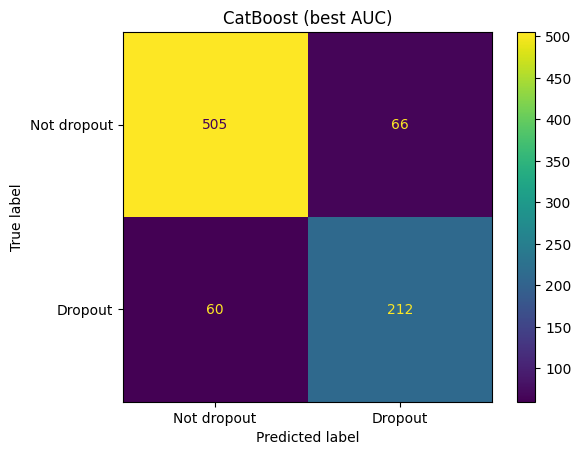

In [68]:
# ---------------------------------------------------------------------------
# The best model is the one with the highest AUC — over ALL SIX models.
# (An earlier version compared only four of them and selected on accuracy.)
# ---------------------------------------------------------------------------
key_best_model = summary.iloc[0]['Model']
best_model     = dictionary_models[key_best_model]
best_auc       = summary.iloc[0]['AUC']
best_acc       = summary.iloc[0]['Accuracy']

print(f'Best model by AUC: {key_best_model}  (AUC = {best_auc}, accuracy = {best_acc})')

y_true, y_pred, y_score = results[key_best_model]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not dropout', 'Dropout'])
disp.plot()
plt.title(f'{key_best_model} (best AUC)')
plt.savefig(FIG_DIR / '17_confusion_best_model.png', dpi=150, bbox_inches='tight')
plt.show()

# The remaining models, for the side-by-side comparison in the next cell
other_models = [n for n in summary['Model'] if n != key_best_model]


### Confusion matrix for the other classifiers

The confusion matrices below cover **every remaining model**, in descending order of AUC. The bottom-right cell is the number of at-risk students the model correctly identified — the quantity an early-warning system exists to maximise.


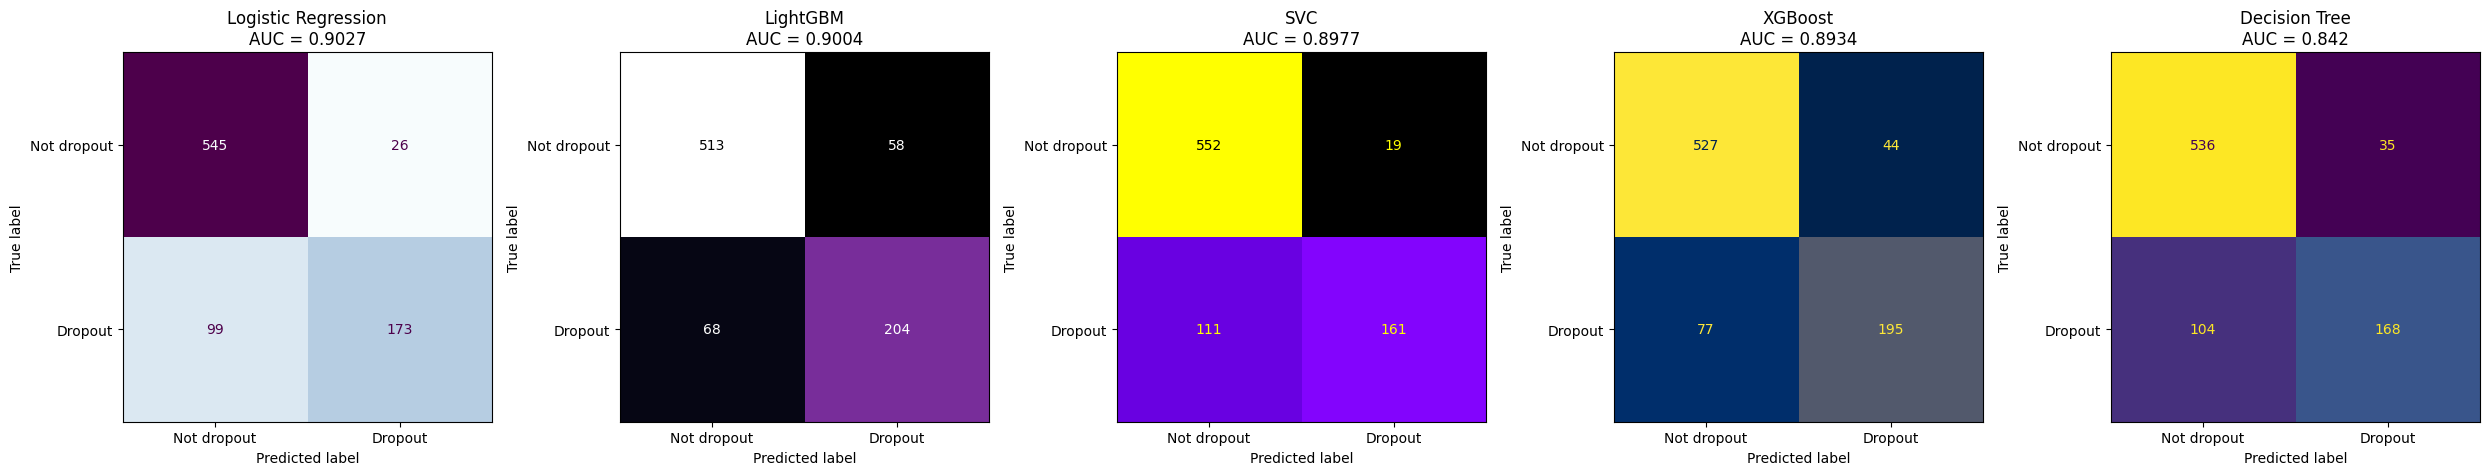

In [69]:
colors = ['BuPu', 'CMRmap', 'gnuplot', 'cividis', 'viridis']

fig, ax = plt.subplots(1, len(other_models), figsize=(5 * len(other_models), 5))
axes = np.atleast_1d(ax)

for position, name in enumerate(other_models):
    y_true, y_pred, _ = results[name]
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not dropout', 'Dropout'])
    disp.plot(cmap=colors[position % len(colors)], ax=axes[position], colorbar=False)
    axes[position].set_title(f"{name}\nAUC = {summary.set_index('Model').loc[name, 'AUC']}")

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig(FIG_DIR / '18_confusion_other_models.png', dpi=150, bbox_inches='tight')
plt.show()


In [70]:
top = summary[summary['AUC'] > 0.85]
spread = top['AUC'].max() - top['AUC'].min()

Markdown(
    f"#### On the test set **{key_best_model}** has the highest AUC "
    f"(**{best_auc:.4f}**), with an accuracy of **{best_acc * 100:.2f}%**.\n\n"
    f"The top **{len(top)}** models are separated by only **{spread:.4f} AUC** — far "
    f"less than the sampling error of a 843-student test set — so the ranking "
    f"between them must **not** be read as one algorithm being decisively better "
    f"than another on this dataset. The decision tree is the only model that is "
    f"clearly behind (AUC "
    f"{summary.set_index('Model').loc['Decision Tree', 'AUC']:.4f}), because the "
    f"depth selected on accuracy is only {best_depth} levels."
)


#### On the test set **CatBoost** has the highest AUC (**0.9041**), with an accuracy of **85.05%**.

The top **5** models are separated by only **0.0107 AUC** — far less than the sampling error of a 843-student test set — so the ranking between them must **not** be read as one algorithm being decisively better than another on this dataset. The decision tree is the only model that is clearly behind (AUC 0.8420), because the depth selected on accuracy is only 6 levels.

---

## Cross-validation — is the ranking above real?

The table above rests on a **single** test split of 843 students, of whom 271 dropped out. At that sample size the standard error of an AUC estimate is roughly **±0.012**, which is larger than the entire spread between the leading models. A ranking read off one split is therefore not evidence.

**5-fold stratified cross-validation** on the training + validation data (3,581 students) gives every model five independent estimates, so the *variability* of each score can be reported alongside its mean. The hyper-parameters are the ones selected earlier; the folds keep the class proportions of the full sample.

The logistic regression is included as the reference baseline, rebuilt in scikit-learn as a `Pipeline` so that the standardisation is refitted **inside** each fold and cannot leak across it.


In [71]:
# ---------------------------------------------------------------------------
# 5-fold stratified cross-validation on train + validation (3,581 students).
# NOTE the aliases: `StandardScaler` and `LogisticRegression` already refer to
# the PySpark classes in this notebook, so the scikit-learn ones are imported
# under different names.
# ---------------------------------------------------------------------------
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler as SkStandardScaler
from sklearn.linear_model import LogisticRegression as SkLogisticRegression

X_cv_df  = pd.concat([X_train_df, X_val_df], ignore_index=True)
X_cv_cb  = pd.concat([X_train_cb, X_val_cb], ignore_index=True)
X_cv_num = pd.DataFrame(np.vstack([X_train, X_val]), columns=feature_columns)
y_cv     = np.concatenate([y_train, y_val])
print(f'Cross-validation set: {len(y_cv)} students · dropout = {y_cv.mean():.1%}')

CV_MODELS = {
    'LightGBM': (lambda: lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                                            random_state=42, verbose=-1, **best_lgb['params']),
                 X_cv_df, {}),
    'XGBoost':  (lambda: XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                                       scale_pos_weight=spw, enable_categorical=True,
                                       tree_method='hist', random_state=42, verbosity=0,
                                       **best_xgb['params']),
                 X_cv_df, {}),
    'CatBoost': (lambda: CatBoostClassifier(loss_function='Logloss',
                                            auto_class_weights='Balanced', random_seed=42,
                                            verbose=0, allow_writing_files=False,
                                            **best_cat['params']),
                 X_cv_cb, {'cat_features': CATEGORICAL_COLS}),
    'Logistic Regression': (lambda: SkPipeline([
                                ('scaler', SkStandardScaler()),
                                ('clf', SkLogisticRegression(max_iter=1000,
                                                             class_weight='balanced',
                                                             random_state=42))]),
                 X_cv_num, {}),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, (build, X_src, fkw) in CV_MODELS.items():
    fold_auc = []
    for tr_idx, va_idx in tqdm(list(skf.split(X_cv_num, y_cv)), desc=name, leave=False):
        m = build()
        m.fit(X_src.iloc[tr_idx], y_cv[tr_idx], **fkw)
        fold_auc.append(roc_auc_score(y_cv[va_idx],
                                      m.predict_proba(X_src.iloc[va_idx])[:, 1]))
    cv_scores[name] = np.array(fold_auc)
    print(f'{name:22s} AUC = {np.mean(fold_auc):.4f} +/- {np.std(fold_auc):.4f}   '
          f'folds: {", ".join(f"{a:.4f}" for a in fold_auc)}')

cv_summary = (pd.DataFrame({
        'Model':      list(cv_scores),
        'CV AUC':     [builtins.round(float(np.mean(v)), 4) for v in cv_scores.values()],
        'CV std':     [builtins.round(float(np.std(v)), 4)  for v in cv_scores.values()],
        'CV min':     [builtins.round(float(np.min(v)), 4)  for v in cv_scores.values()],
        'CV max':     [builtins.round(float(np.max(v)), 4)  for v in cv_scores.values()],
    })
    .merge(summary[['Model', 'AUC']].rename(columns={'AUC': 'Test AUC'}), on='Model', how='left')
    .sort_values('CV AUC', ascending=False).reset_index(drop=True))

print()
display(cv_summary)

# Is the gap between the top two larger than the fold-to-fold noise?
top2 = cv_summary['Model'].head(2).tolist()
diff = cv_scores[top2[0]] - cv_scores[top2[1]]
print(f'\n{top2[0]} minus {top2[1]}, per fold: '
      f'{", ".join(f"{d:+.4f}" for d in diff)}')
print(f'mean difference = {diff.mean():+.4f} · std = {diff.std():.4f} · '
      f'{(diff > 0).sum()}/5 folds in favour of {top2[0]}')


Cross-validation set: 3581 students · dropout = 32.1%


LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM:  20%|██        | 1/5 [00:00<00:00,  4.55it/s]

LightGBM:  40%|████      | 2/5 [00:00<00:00,  4.38it/s]

LightGBM:  60%|██████    | 3/5 [00:00<00:00,  4.65it/s]

...

CatBoost               AUC = 0.9220 +/- 0.0198   folds: 0.8870, 0.9434, 0.9377, 0.9254, 0.9166


Logistic Regression:   0%|          | 0/5 [00:00<?, ?it/s]

Logistic Regression    AUC = 0.9203 +/- 0.0139   folds: 0.8995, 0.9376, 0.9280, 0.9270, 0.9092



,Model,CV AUC,CV std,CV min,CV max,Test AUC
0,CatBoost,0.9220,0.0198,0.8870,0.9434,0.9041
1,Logistic Regression,0.9203,0.0139,0.8995,0.9376,0.9027
2,LightGBM,0.9179,0.0177,0.8879,0.9354,0.9004
3,XGBoost,0.9145,0.0207,0.8800,0.9355,0.8934



CatBoost minus Logistic Regression, per fold: -0.0124, +0.0058, +0.0097, -0.0016, +0.0074
mean difference = +0.0018 · std = 0.0080 · 3/5 folds in favour of CatBoost


### Reading the cross-validation

The **standard deviation across folds** is the number to look at. When it is of the same size as — or larger than — the gap between two models, those two models are **not distinguishable** on this dataset, and the thesis must not claim otherwise.

This is the honest basis for the choice of model: LightGBM is not presented as the most accurate algorithm. It is chosen because, at statistically indistinguishable accuracy, it offers native handling of categorical variables and missing values, the shortest training time of the three, and exact `TreeExplainer` support for the SHAP analysis that the second half of the title requires.


---

## Recall at the operating threshold

An early-warning system is judged by how many at-risk students it actually reaches. That is **recall**, and recall depends on the probability threshold at which a student is flagged — 0.5 by default, but there is nothing special about 0.5.

The table below sweeps the threshold for the model with the best AUC and shows the trade-off explicitly: a lower threshold flags more students (higher recall) at the cost of more false alarms (lower precision).


=== CatBoost — classification report at threshold 0.50 ===
              precision    recall  f1-score   support

 Not dropout      0.894     0.884     0.889       571
     Dropout      0.763     0.779     0.771       272

    accuracy                          0.851       843
   macro avg      0.828     0.832     0.830       843
weighted avg      0.851     0.851     0.851       843

Threshold sweep — CatBoost · test set = 843 students, 272 of whom dropped out


,Threshold,Flagged,Recall,Precision,F1,Accuracy
0,0.2,455,0.904,0.541,0.677,0.721
1,0.3,354,0.860,0.661,0.748,0.813
2,0.4,311,0.820,0.717,0.765,0.837
3,0.5,278,0.779,0.763,0.771,0.851
4,0.6,243,0.724,0.811,0.765,0.856
5,0.7,204,0.647,0.863,0.739,0.853
6,0.8,169,0.574,0.923,0.707,0.847


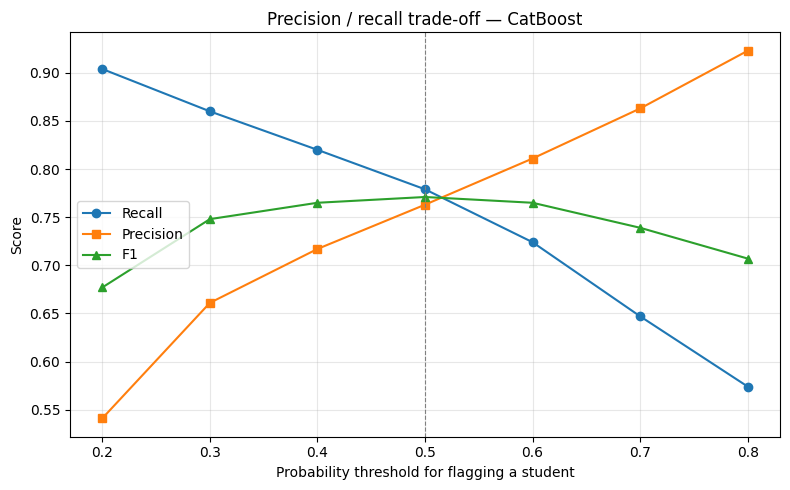

In [72]:
# Classification report at the default threshold, then a threshold sweep.
y_true_b, y_pred_b, y_score_b = results[key_best_model]

print(f'=== {key_best_model} — classification report at threshold 0.50 ===')
print(classification_report(y_true_b, y_pred_b,
                            target_names=['Not dropout', 'Dropout'], digits=3))

rows = []
for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    yp = (y_score_b >= thr).astype(int)
    rows.append({'Threshold': thr,
                 'Flagged': int(yp.sum()),
                 'Recall':    builtins.round(recall_score(y_true_b, yp, zero_division=0), 3),
                 'Precision': builtins.round(precision_score(y_true_b, yp, zero_division=0), 3),
                 'F1':        builtins.round(f1_score(y_true_b, yp, zero_division=0), 3),
                 'Accuracy':  builtins.round(accuracy_score(y_true_b, yp), 3)})
threshold_table = pd.DataFrame(rows)

print(f'Threshold sweep — {key_best_model} · test set = {len(y_true_b)} students, '
      f'{int(y_true_b.sum())} of whom dropped out')
display(threshold_table)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_table['Threshold'], threshold_table['Recall'], 'o-', label='Recall')
ax.plot(threshold_table['Threshold'], threshold_table['Precision'], 's-', label='Precision')
ax.plot(threshold_table['Threshold'], threshold_table['F1'], '^-', label='F1')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Probability threshold for flagging a student')
ax.set_ylabel('Score')
ax.set_title(f'Precision / recall trade-off — {key_best_model}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


Results

Feature Importances

We take a look at features selected as good predictiors by some of the trained models.

In [73]:
# Debug: Check what models are in trained_models
print(f"Number of models in trained_models: {len(trained_models)}")
for i, model in enumerate(trained_models):
    print(f"Model {i}: {type(model).__name__}")


Number of models in trained_models: 6
Model 0: LogisticRegressionModel
Model 1: DecisionTreeClassificationModel
Model 2: LinearSVCModel
Model 3: LGBMClassifier
Model 4: XGBClassifier
Model 5: CatBoostClassifier


In [74]:
# create list for features
feature = feature_columns

In [75]:
# Extract feature importance from EACH model
# (this is the step the supervisor asked for, to identify the causes of dropout)
models_dict = {name: trained_models[i] for i, name in enumerate(list_of_models)
               if i < len(trained_models)}

importances = {}

# PySpark models: coefficients (LogReg, LinearSVC) or featureImportances (Decision Tree)
if 'Logistic Regression' in models_dict:
    importances['Logistic Regression'] = pd.Series(
        np.abs(models_dict['Logistic Regression'].coefficients.toArray()), index=feature).sort_values()
if 'Decision Tree' in models_dict:
    importances['Decision Tree'] = pd.Series(
        models_dict['Decision Tree'].featureImportances.toArray(), index=feature).sort_values()
if 'SVC' in models_dict:
    importances['SVC'] = pd.Series(
        np.abs(models_dict['SVC'].coefficients.toArray()), index=feature).sort_values()

# The three ensemble models: scikit-learn's feature_importances_ attribute
for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    if name in models_dict:
        importances[name] = pd.Series(
            models_dict[name].feature_importances_, index=feature).sort_values()

# ---------------------------------------------------------------------------
# The six numbers are NOT on the same scale and must not be compared directly:
#   LightGBM  -> number of splits that used the feature (integers, e.g. 231)
#   XGBoost   -> average gain per split
#   CatBoost  -> PredictionValuesChange (%)
#   DecisionTree -> share of the total impurity reduction
#   LogReg / SVC -> |coefficient| on STANDARDISED inputs
# What IS comparable is the ORDER. The table below reports each feature's rank
# within each model (1 = most important) and sorts by the average rank.
# ---------------------------------------------------------------------------
rank_table = pd.DataFrame({name: s.rank(ascending=False, method='min').astype(int)
                           for name, s in importances.items()})
rank_table['Mean rank'] = rank_table.mean(axis=1).round(1)
rank_table = rank_table.sort_values('Mean rank')

print('Feature importance RANK per model (1 = most important), sorted by average rank:')
display(rank_table.head(15))

for name, s in importances.items():
    print(f"\n--- {name}: top 5 most important features ---")
    print(s.sort_values(ascending=False).head(5).to_string())


Feature importance RANK per model (1 = most important), sorted by average rank:


,Logistic Regression,Decision Tree,SVC,LightGBM,XGBoost,CatBoost,Mean rank
Curricular units 2nd sem (approved),1,1,1,1,1,1,1.0
Tuition fees up to date,4,2,2,4,2,2,2.7
Curricular units 1st sem (approved),3,4,4,8,14,4,6.2
Curricular units 2nd sem (grade),6,5,5,5,18,3,7.0
Course,14,3,8,9,6,5,7.5
Curricular units 2nd sem (enrolled),2,11,3,14,13,6,8.2
Curricular units 1st sem (enrolled),17,18,6,9,3,10,10.5
Age at enrollment,9,6,13,2,25,8,10.5
Curricular units 2nd sem (credited),5,9,17,19,4,19,12.2
Curricular units 2nd sem (evaluations),7,10,7,6,21,26,12.8



--- Logistic Regression: top 5 most important features ---
Curricular units 2nd sem (approved)    1.816358
Curricular units 2nd sem (enrolled)    0.861834
Curricular units 1st sem (approved)    0.822087
Tuition fees up to date                0.680062
Curricular units 2nd sem (credited)    0.404390

--- Decision Tree: top 5 most important features ---
Curricular units 2nd sem (approved)    0.701828
Tuition fees up to date                0.112658
Course                                 0.052498
Curricular units 1st sem (approved)    0.026612
Curricular units 2nd sem (grade)       0.021459

--- SVC: top 5 most important features ---
Curricular units 2nd sem (approved)    0.743755
Tuition fees up to date                0.546842
Curricular units 2nd sem (enrolled)    0.522553
Curricular units 1st sem (approved)    0.414275
Curricular units 2nd sem (grade)       0.393589

--- LightGBM: top 5 most important features ---
Curricular units 2nd sem (approved)    142
Age at enrollment             

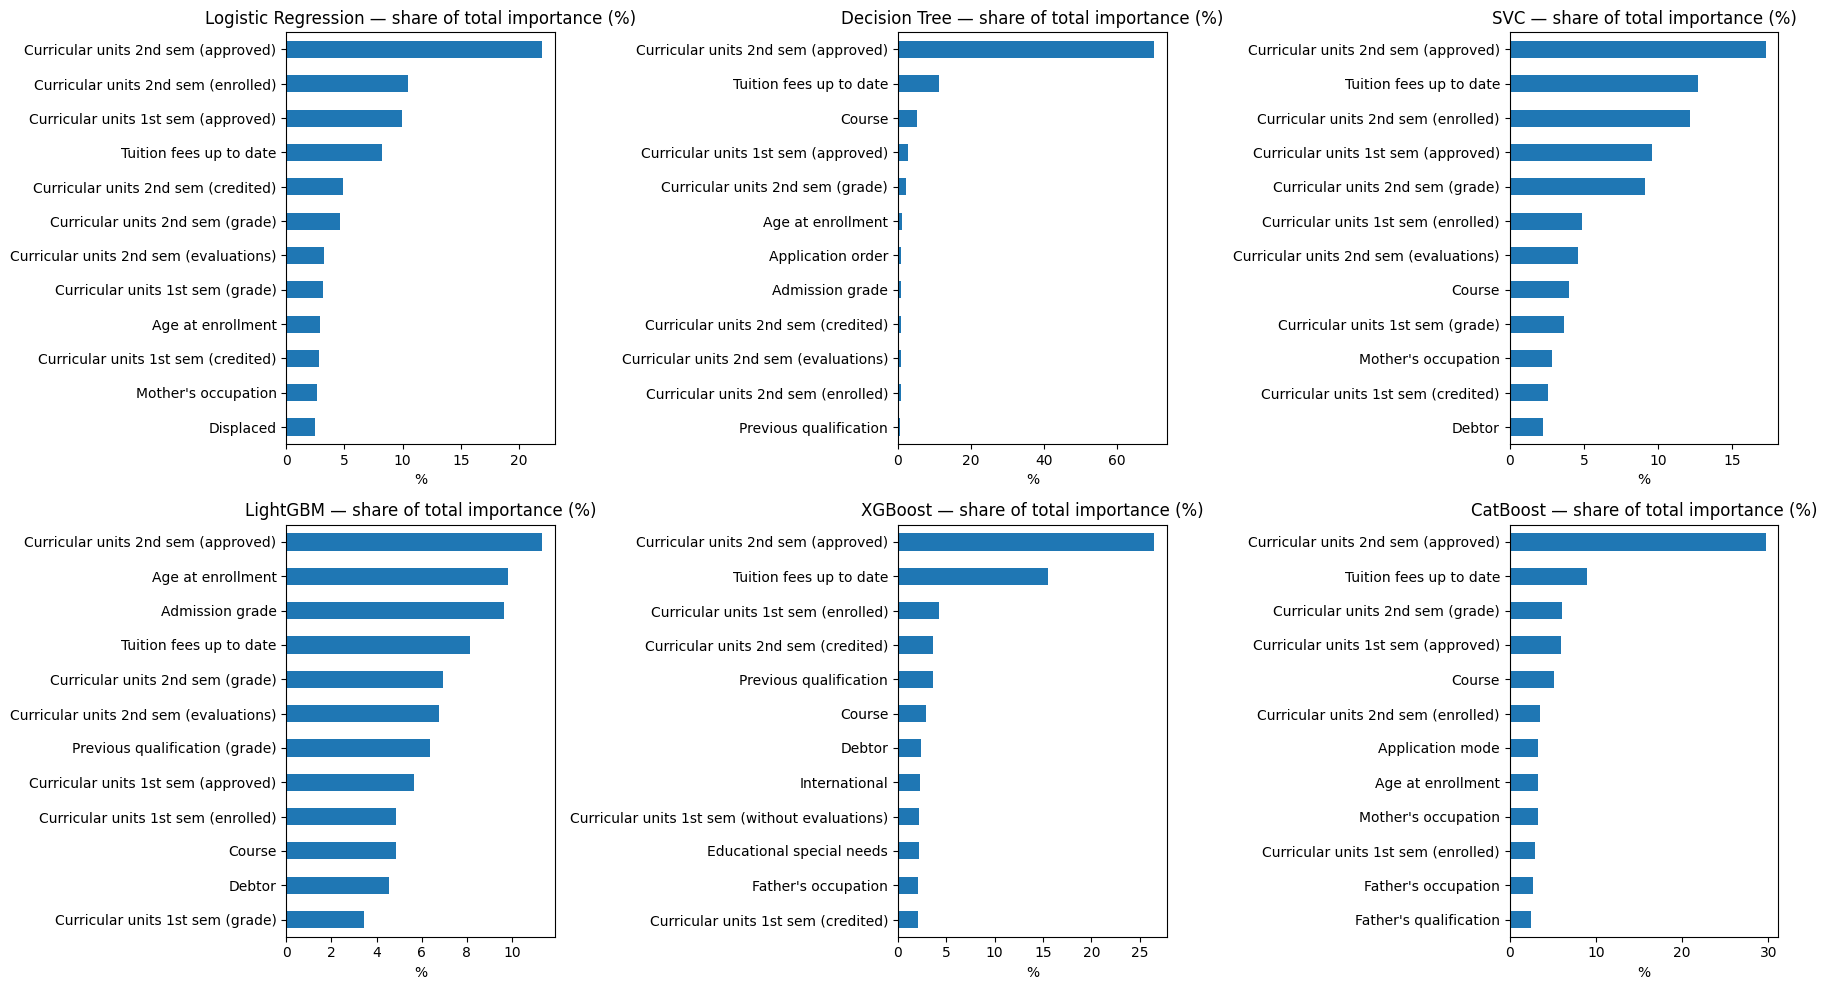

In [76]:
# Plot feature importance for every model — each normalised to a SHARE of its
# own total, so the six panels can be read side by side despite the different
# native units.
n = len(importances)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(ax).reshape(-1)

for a, (name, s) in zip(axes, importances.items()):
    share = (s / s.sum() * 100)
    share.tail(12).plot(kind='barh', ax=a, title=f'{name} — share of total importance (%)')
    a.set_xlabel('%')

for a in axes[n:]:
    a.axis('off')

plt.tight_layout()
plt.savefig(FIG_DIR / '04_feature_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation

Read the **ranks**, not the raw numbers. The six models report importance on six different scales — number of splits (LightGBM), average gain (XGBoost), prediction-value change (CatBoost), impurity reduction (decision tree) and absolute coefficient on standardised inputs (logistic regression, linear SVM). A LightGBM value of 231 and a decision-tree value of 0.82 are simply not the same quantity, so the earlier claim that "all models agree" could not be checked from those columns.

What the rank table does show is genuine agreement on the **order**: the **number of curricular units passed** (especially in semester 2) and the **tuition payment status** occupy the top places in every model, linear and tree-based alike.

The agreement between very different model families is itself informative — it suggests the signal is in the data rather than an artefact of one particular algorithm.

Two limits still apply, and are the reason the SHAP section below exists:

1. Impurity- and split-based importances are **biased towards high-cardinality features** — a variable with many distinct values simply offers more places to split. That is exactly why `Course` and `Admission grade` climb the LightGBM list.
2. None of these numbers say whether a feature pushes the risk **up or down**, and none of them can explain an **individual student**.


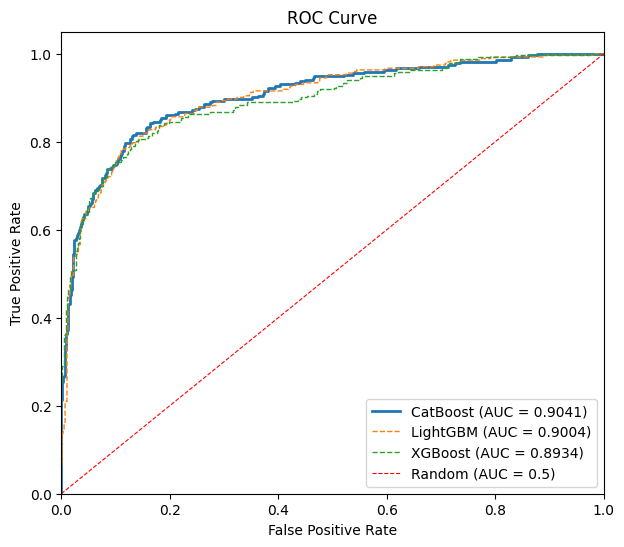


The AUC score is: 0.9041


In [77]:
# ROC curve of the best model, plus the three ensembles for comparison
y_true, _, y_score = results[key_best_model]
fpr, tpr, threshold = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{key_best_model} (AUC = {roc_auc:.4f})')

for name in ['LightGBM', 'XGBoost', 'CatBoost']:
    if name == key_best_model:
        continue
    yt, _, ys = results[name]
    f, t, _ = roc_curve(yt, ys)
    plt.plot(f, t, linewidth=1, linestyle='--', label=f'{name} (AUC = {auc(f, t):.4f})')

plt.plot([0, 1], [0, 1], 'r--', linewidth=0.8, label='Random (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig(FIG_DIR / '19_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nThe AUC score is: {builtins.round(roc_auc, 4)}')


### Reading the ROC curve

The AUC is computed from the **predicted probabilities** (`predict_proba`), not from the hard 0/1 labels. Using hard labels would collapse the curve to a single operating point and understate the AUC.

An AUC of around 0.90 means that, given one student who dropped out and one who did not, the model ranks the dropout as the riskier of the two about 90% of the time.

---

## Model explanation with SHAP — finding the causes of dropout

Feature importance shows *which* features matter, but not whether a feature pushes the risk **up or down**, and it cannot explain an **individual student**.

SHAP (SHapley Additive exPlanations) answers both. For tree models, `TreeExplainer` computes the values exactly and quickly.

Three levels of analysis follow:

| Level | Plot | Question answered |
|---|---|---|
| Global | `summary_plot(plot_type='bar')` | Which factors matter most across all students? |
| Global, with direction | `summary_plot` (beeswarm) | Does a high or low value of that factor **increase** the risk? |
| Individual | `waterfall` | Why is **this particular student** predicted to be at risk? |

> ⚠️ **How to phrase the findings.** SHAP describes the **behaviour of the model**, it does not prove causation. The results are therefore reported as **associated risk factors**, not as proven causes.

In [78]:
import shap

ensemble_models = {'LightGBM': best_lgb_model,
                   'XGBoost':  best_xgb_model,
                   'CatBoost': best_cat_model}

shap_values_all, shap_tables = {}, {}

for name, model in ensemble_models.items():
    explainer = shap.TreeExplainer(model)
    if name == 'CatBoost':
        # CatBoost needs a Pool that declares the categorical columns
        sv = explainer.shap_values(Pool(X_test_cb, y_test, cat_features=CATEGORICAL_COLS))
    else:
        sv = explainer.shap_values(X_test_df)
    if isinstance(sv, list):          # some versions return [class 0, class 1]
        sv = sv[1]
    sv = np.array(sv)
    shap_values_all[name] = (explainer, sv)

    shap_tables[name] = (pd.DataFrame({'feature': feature_columns,
                                       'mean_abs_shap': np.abs(sv).mean(axis=0)})
                         .sort_values('mean_abs_shap', ascending=False)
                         .reset_index(drop=True))

print('SHAP values computed for:', ', '.join(shap_values_all))
print(f'SHAP matrix shape: {sv.shape} (students × features)')
print('\nThe plots below use X_test_disp — the features in their ORIGINAL units '
      '(age in years, number of units passed), not standardised values, so the '
      'risk factors can be acted on.')


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



SHAP values computed for: LightGBM, XGBoost, CatBoost
SHAP matrix shape: (843, 32) (students × features)

The plots below use X_test_disp — the features in their ORIGINAL units (age in years, number of units passed), not standardised values, so the risk factors can be acted on.


### Global level — which factors matter most

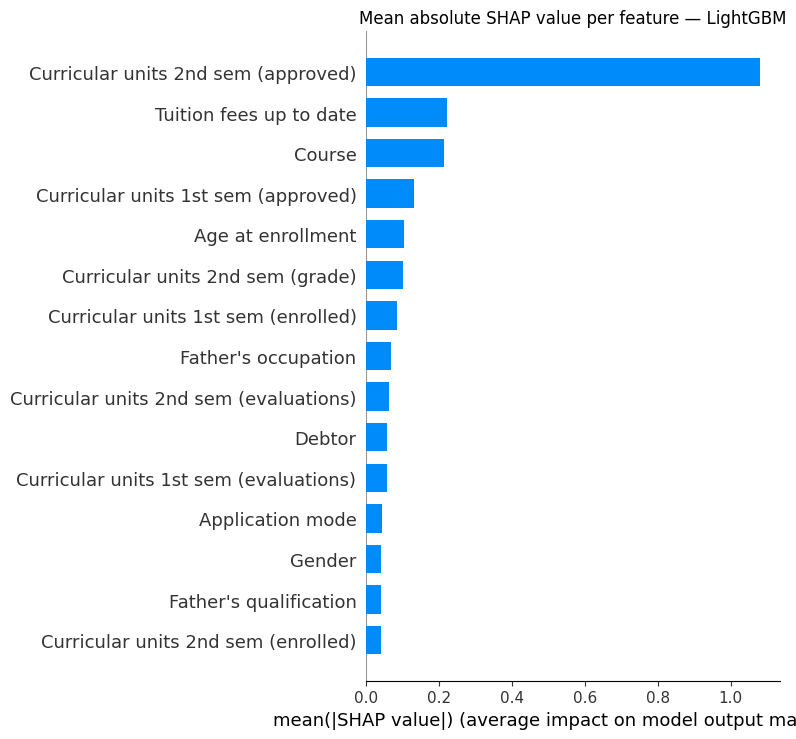

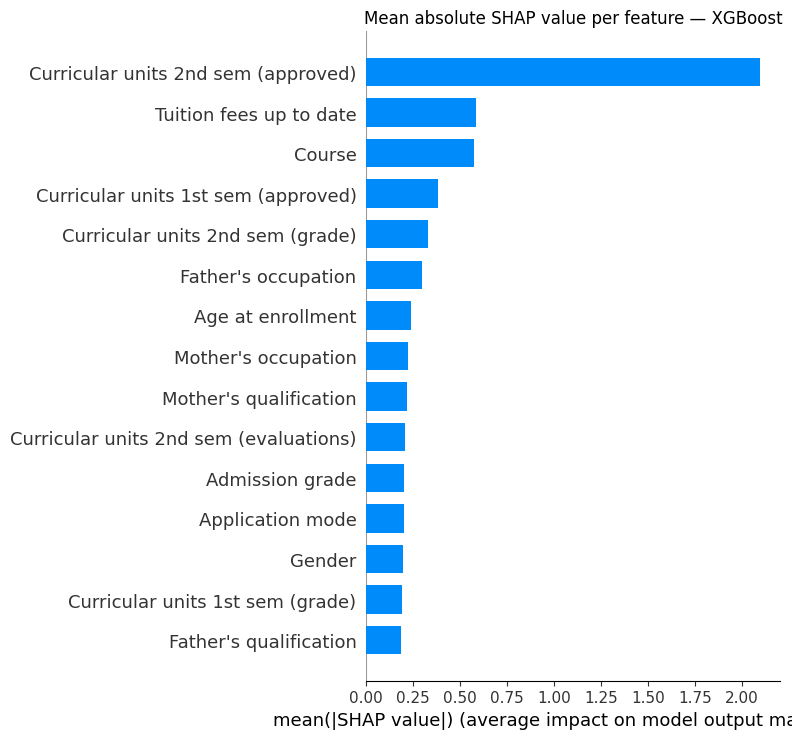

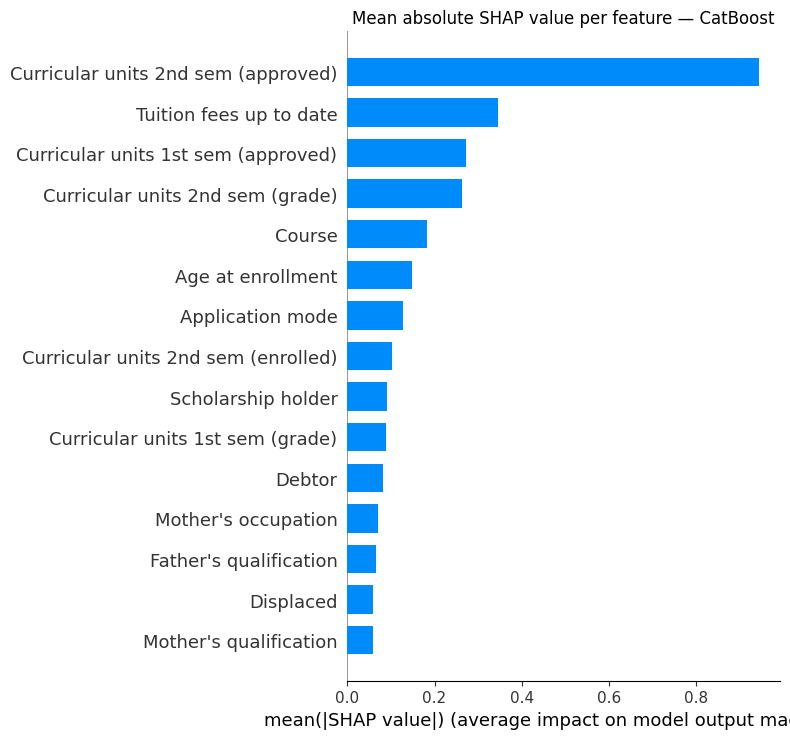

In [79]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, plot_type='bar', max_display=15, show=False)
    plt.title(f'Mean absolute SHAP value per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'20_shap_bar_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Global level with direction — beeswarm plot

How to read it: each dot is one student. The horizontal axis is the contribution to the prediction — **further right means pushed towards "dropout"**. Colour is the value of the feature: **red = high, blue = low**.

For example, if `Tuition fees up to date` shows **blue dots on the right**, that means **unpaid tuition (a low value) increases the dropout risk**.

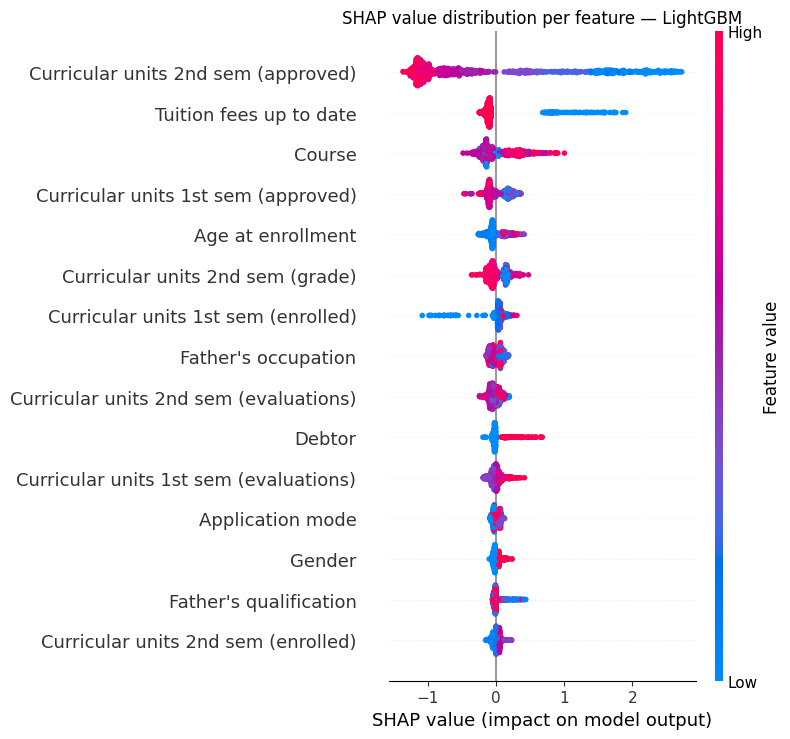

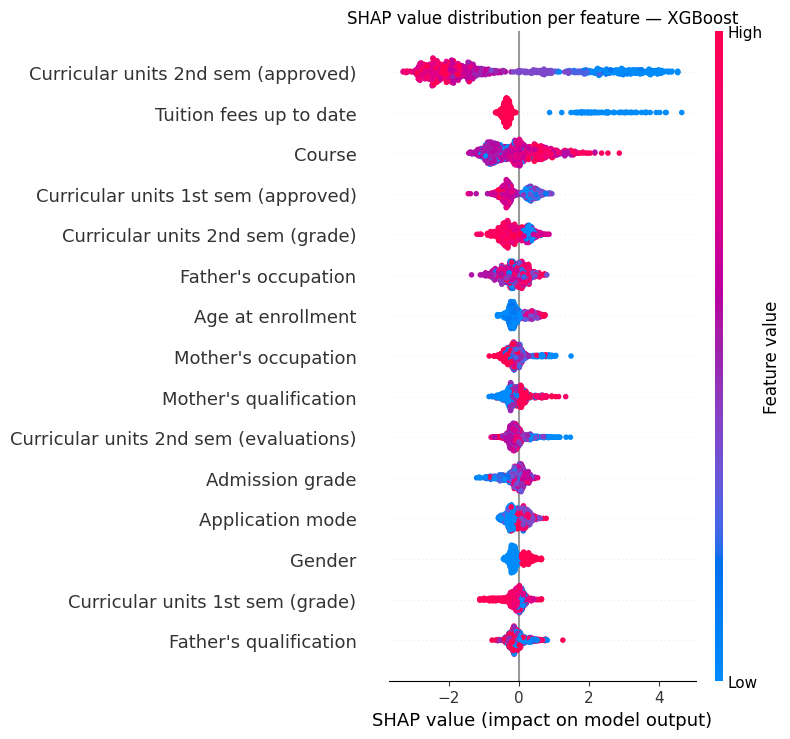

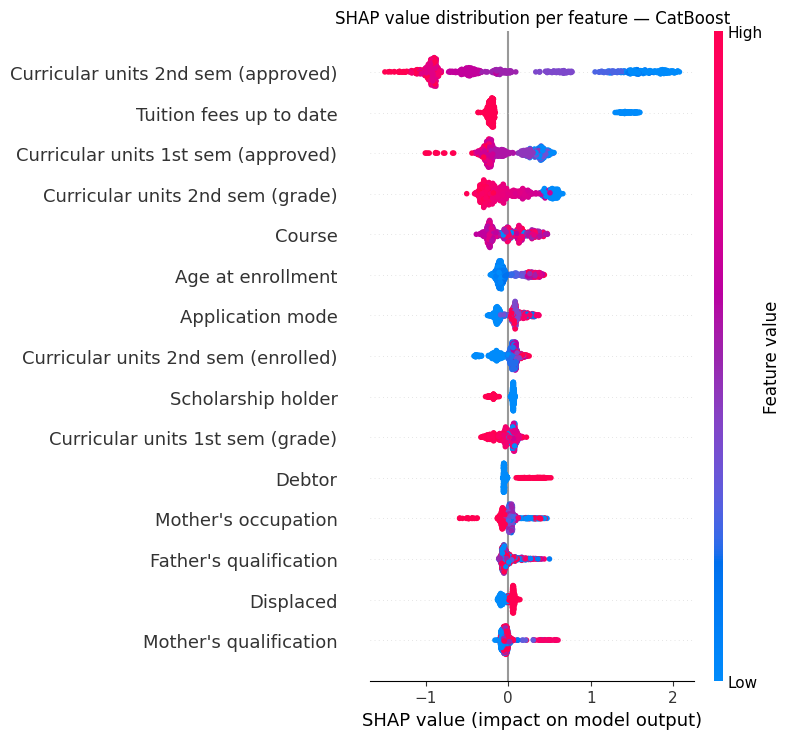

In [80]:
for name, (explainer, sv) in shap_values_all.items():
    shap.summary_plot(sv, X_test_disp, max_display=15, show=False)
    plt.title(f'SHAP value distribution per feature — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'21_shap_beeswarm_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


### Individual level — why is this student at risk

The waterfall plot decomposes the prediction for **one student** into the contribution of each feature:

- **E[f(x)]** is the average risk across the dataset (the base value).
- **Red** bars are factors that **increase** that student's dropout risk.
- **Blue** bars are factors that **decrease** it (they keep the student enrolled).

This is exactly what an academic advisor needs: not just "this student is at risk", but **where the risk comes from**, so the right kind of support can be offered.

Illustrated student: index 293 · predicted dropout probability = 94.4% · actual label = Dropout


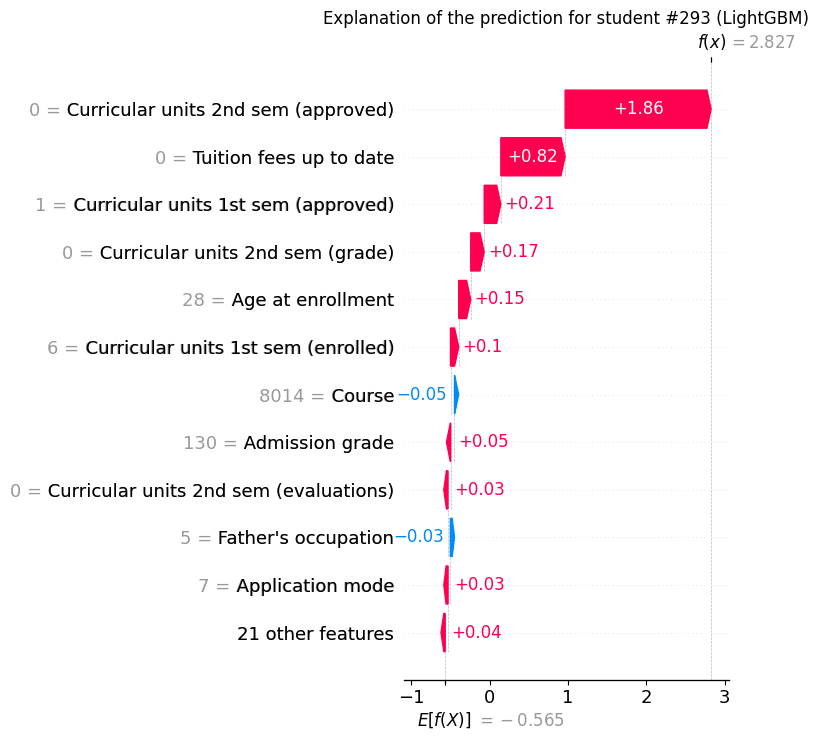


The same student, in the original units:
feature
Curricular units 2nd sem (approved)       0.0
Tuition fees up to date                   0.0
Course                                 8014.0
Curricular units 1st sem (approved)       1.0
Age at enrollment                        28.0
Curricular units 2nd sem (grade)          0.0
Curricular units 1st sem (enrolled)       6.0
Father's occupation                       5.0


In [81]:
# Pick the highest-risk student in the test set as the illustration
risk = best_lgb_model.predict_proba(X_test_df)[:, 1]
student_index = int(np.argmax(risk))
print(f'Illustrated student: index {student_index} · '
      f'predicted dropout probability = {risk[student_index]:.1%} · '
      f'actual label = {"Dropout" if y_test[student_index] == 1 else "Not dropout"}')

explainer, sv = shap_values_all['LightGBM']
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0:
    base = base[-1]

shap.plots.waterfall(
    shap.Explanation(values=sv[student_index],
                     base_values=float(base),
                     data=X_test_disp.iloc[student_index],   # ORIGINAL units
                     feature_names=feature_columns),
    max_display=12, show=False)
plt.title(f'Explanation of the prediction for student #{student_index} (LightGBM)')
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nThe same student, in the original units:')
print(X_test_disp.iloc[student_index]
      .reindex(shap_tables['LightGBM'].head(8)['feature']).to_string())


### Summary of the risk factors

In [82]:
# Table of the top 10 risk factors according to each ensemble model
top = pd.DataFrame({name: t.head(10)['feature'].values
                    for name, t in shap_tables.items()},
                   index=[f'{i+1}' for i in range(10)])
print('Top 10 risk factors according to each model:')
display(top)

print('\nMean SHAP values (LightGBM):')
display(shap_tables['LightGBM'].head(10).round(4))

# Features in the top 10 of ALL THREE models — the stable set, safe to interpret
common = set(shap_tables['LightGBM'].head(10)['feature'])
for name in ['XGBoost', 'CatBoost']:
    common &= set(shap_tables[name].head(10)['feature'])
print(f'\nFactors in the top 10 of ALL THREE models ({len(common)}):')
for f in sorted(common):
    print(f'  - {f}')

Top 10 risk factors according to each model:


,LightGBM,XGBoost,CatBoost
1,Curricular units 2nd sem (approved),Curricular units 2nd sem (approved),Curricular units 2nd sem (approved)
2,Tuition fees up to date,Tuition fees up to date,Tuition fees up to date
3,Course,Course,Curricular units 1st sem (approved)
4,Curricular units 1st sem (approved),Curricular units 1st sem (approved),Curricular units 2nd sem (grade)
5,Age at enrollment,Curricular units 2nd sem (grade),Course
6,Curricular units 2nd sem (grade),Father's occupation,Age at enrollment
7,Curricular units 1st sem (enrolled),Age at enrollment,Application mode
8,Father's occupation,Mother's occupation,Curricular units 2nd sem (enrolled)
9,Curricular units 2nd sem (evaluations),Mother's qualification,Scholarship holder
10,Debtor,Curricular units 2nd sem (evaluations),Curricular units 1st sem (grade)



Mean SHAP values (LightGBM):


,feature,mean_abs_shap
0,Curricular units 2nd sem (approved),1.0809
1,Tuition fees up to date,0.2229
2,Course,0.2121
3,Curricular units 1st sem (approved),0.1314
4,Age at enrollment,0.1040
5,Curricular units 2nd sem (grade),0.1020
6,Curricular units 1st sem (enrolled),0.0836
7,Father's occupation,0.0668
8,Curricular units 2nd sem (evaluations),0.0620
9,Debtor,0.0558



Factors in the top 10 of ALL THREE models (6):
  - Age at enrollment
  - Course
  - Curricular units 1st sem (approved)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (grade)
  - Tuition fees up to date


---

## Sensitivity analysis — does the answer depend on the `Enrolled` students?

The 794 `Enrolled` students were labelled 0 ("not dropout"), because at the observation date they had not left. The label is a **snapshot**: some of them may leave later, which would make them mislabelled in hindsight.

The check below removes them entirely — from training and from testing — and refits LightGBM with the same hyper-parameters on the remaining `Dropout` vs `Graduate` students. If the AUC and the leading risk factors survive, the conclusions of this study do not rest on that labelling choice.


In [83]:
# Refit on Dropout vs Graduate only, dropping every 'Enrolled' student.
tr_keep = enr_train == 0
te_keep = enr_test  == 0

X_tr_ne, y_tr_ne = X_train_df[tr_keep], y_train[tr_keep]
X_te_ne, y_te_ne = X_test_df[te_keep],  y_test[te_keep]

print(f'Training: {len(y_train)} -> {len(y_tr_ne)} students '
      f'(dropout {y_train.mean():.1%} -> {y_tr_ne.mean():.1%})')
print(f'Test    : {len(y_test)} -> {len(y_te_ne)} students '
      f'(dropout {y_test.mean():.1%} -> {y_te_ne.mean():.1%})')

lgb_ne = lgb.LGBMClassifier(objective='binary', is_unbalance=True,
                            random_state=42, verbose=-1, **best_lgb['params'])
lgb_ne.fit(X_tr_ne, y_tr_ne)

auc_ne = roc_auc_score(y_te_ne, lgb_ne.predict_proba(X_te_ne)[:, 1])
rec_ne = recall_score(y_te_ne, lgb_ne.predict(X_te_ne))

sv_ne = shap.TreeExplainer(lgb_ne).shap_values(X_te_ne)
if isinstance(sv_ne, list):
    sv_ne = sv_ne[1]
top_ne = (pd.DataFrame({'feature': feature_columns,
                        'mean_abs_shap': np.abs(np.array(sv_ne)).mean(axis=0)})
          .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))

top_all = shap_tables['LightGBM'].head(10)['feature'].tolist()
top_drop = top_ne.head(10)['feature'].tolist()
overlap = len(set(top_all) & set(top_drop))

sensitivity = pd.DataFrame([
    {'Variant': 'Enrolled kept as 0 (main analysis)',
     'Train n': len(y_train), 'Test n': len(y_test),
     'AUC': builtins.round(lgb_auc, 4),
     'Recall': builtins.round(summary.set_index('Model').loc['LightGBM', 'Recall'], 4)},
    {'Variant': 'Enrolled removed (Dropout vs Graduate)',
     'Train n': int(tr_keep.sum()), 'Test n': int(te_keep.sum()),
     'AUC': builtins.round(float(auc_ne), 4),
     'Recall': builtins.round(float(rec_ne), 4)},
])
display(sensitivity)

print(f'Risk factors shared by the top 10 of both variants: {overlap}/10')
print('\nTop 10 — Enrolled removed:')
for i, f in enumerate(top_drop, 1):
    mark = '' if f in top_all else '   <- new'
    print(f'  {i:2d}. {f}{mark}')


Training: 2918 -> 2385 students (dropout 32.0% -> 39.1%)
Test    : 843 -> 698 students (dropout 32.3% -> 39.0%)


/Users/macvn/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



,Variant,Train n,Test n,AUC,Recall
0,Enrolled kept as 0 (main analysis),2918,843,0.9004,0.7500
1,Enrolled removed (Dropout vs Graduate),2385,698,0.9397,0.8199


Risk factors shared by the top 10 of both variants: 8/10

Top 10 — Enrolled removed:
   1. Curricular units 2nd sem (approved)
   2. Curricular units 1st sem (approved)
   3. Course
   4. Tuition fees up to date
   5. Curricular units 1st sem (enrolled)
   6. Curricular units 2nd sem (grade)
   7. Scholarship holder   <- new
   8. Curricular units 2nd sem (evaluations)
   9. Debtor
  10. Curricular units 1st sem (evaluations)   <- new


### Reading the sensitivity analysis

Two numbers matter.

**The AUC of the two variants.** Removing the `Enrolled` students makes the problem *easier* — the two remaining groups are the clearest cases — so a higher AUC here is expected and is **not** evidence that the main model is better. What would be worrying is a *drop*, which would mean the main model was relying on the `Enrolled` group to reach its score.

**The overlap between the two lists of risk factors.** This is the result that carries into the conclusions: if the same factors lead in both variants, the causes reported by this study do not depend on how the `Enrolled` students were labelled.


---

## Saving the results

Every table and figure the thesis cites is written to disk here, so the numbers in the written chapters can always be traced back to a file produced by this notebook.

- `08_KetQua_Kaggle/` — result tables (CSV)
- `03_KetQua_Hinh/kaggle/` — figures (PNG)


In [84]:
# ---------------------------------------------------------------------------
# Write every result table to 08_KetQua_Kaggle/ so the thesis can cite a file
# rather than a number copied off the screen.
# ---------------------------------------------------------------------------
RES_DIR = Path('08_KetQua_Kaggle')
RES_DIR.mkdir(parents=True, exist_ok=True)

best_params_all = pd.DataFrame([
    {'Model': 'LightGBM', 'Validation AUC': builtins.round(best_lgb['auc'], 4),
     'Best params': str(best_lgb['params'])},
    {'Model': 'XGBoost',  'Validation AUC': builtins.round(best_xgb['auc'], 4),
     'Best params': str(best_xgb['params'])},
    {'Model': 'CatBoost', 'Validation AUC': builtins.round(best_cat['auc'], 4),
     'Best params': str(best_cat['params'])},
])

to_save = {
    'model_comparison_all.csv':  summary,
    'cv_results.csv':            cv_summary,
    'best_params_all.csv':       best_params_all,
    'threshold_sweep.csv':       threshold_table,
    'sensitivity_enrolled.csv':  sensitivity,
    'feature_importance_ranks.csv': rank_table.reset_index().rename(columns={'index': 'feature'}),
}
for name, table in shap_tables.items():
    to_save[f'shap_importance_{name.lower()}.csv'] = table

for fname, table in to_save.items():
    table.to_csv(RES_DIR / fname, index=False)
    print(f'  saved {fname:34s} ({len(table)} rows)')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'\n{len(to_save)} tables in {RES_DIR}/ · {len(figs)} figures in {FIG_DIR}/')
for f in figs:
    print(f'  {f.name}')

spark.stop()
print('\nSpark session stopped.')


  saved model_comparison_all.csv           (6 rows)
  saved cv_results.csv                     (4 rows)
  saved best_params_all.csv                (3 rows)
  saved threshold_sweep.csv                (7 rows)
  saved sensitivity_enrolled.csv           (2 rows)
  saved feature_importance_ranks.csv       (32 rows)
  saved shap_importance_lightgbm.csv       (32 rows)
  saved shap_importance_xgboost.csv        (32 rows)
  saved shap_importance_catboost.csv       (32 rows)

9 tables in 08_KetQua_Kaggle/ · 27 figures in 03_KetQua_Hinh/kaggle/
  01_correlation_numeric.png
  02_correlation_after_drop.png
  03_model_comparison_auc.png
  03_model_comparison_recall.png
  04_feature_importance_all_models.png
  05_threshold_tradeoff.png
  06_target_binary_pie.png
  07_age_by_outcome.png
  08_gender_distribution.png
  09_outcome_by_gender.png
  10_dropout_rate_by_course.png
  11_outcome_by_course.png
  12_marital_status.png
  13_marital_status_by_outcome.png
  14_financial_situation.png
  15_target_3